# Rooftop solar potential

I apply the rooftop-irradiation filtering approach of Koch et al. (2022) to Guildford building footprints, then estimate technical PV potential.


In [ ]:
# Review copy: read the saved outputs without executing the research pipeline.
import os
if os.environ.get("ENERMAP_ENABLE_MODEL_RUN") != "1":
    raise RuntimeError("This showcase contains saved outputs. Raw data and third-party engines are excluded. Read the notebook; do not Run All for the presentation.")
import sys
from pathlib import Path
_repo = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "config.py").exists())
sys.path.insert(0, str(_repo))


---
## Cell 0 — Configuration

**Every parameter lives here.**

In [1]:
# ============================================================
# CONFIGURATION
# ============================================================
import os

# --- Inputs -------------------------------------------------
DATA_DIR   = "data"
OUTPUT_DIR = "outputs"

# One folder per spatial unit of analysis, so nothing has to be untangled later.
DIR_TOWN     = os.path.join(OUTPUT_DIR, "town")
DIR_WARD     = os.path.join(OUTPUT_DIR, "ward")
DIR_BUILDING = os.path.join(OUTPUT_DIR, "building")
DIR_RASTER   = os.path.join(OUTPUT_DIR, "raster")
for _d in (OUTPUT_DIR, DIR_TOWN, DIR_WARD, DIR_BUILDING, DIR_RASTER):
    os.makedirs(_d, exist_ok=True)

# Annual global irradiation on roofs (kWh/m2/yr), 1 m, EPSG:27700.
# Produced by UMEP/SEBE from EA National LiDAR Programme point clouds;
# slope and aspect are implicit in the values (Koch et al. 2022, section 2).
IRRAD_PATH = os.path.join(DATA_DIR, "guildford_urban_wards.tif")

# Building footprints. OS MasterMap Topography, already clipped to the Guildford
# urban wards that define the study area, and carrying use-class attribution.
# OS MasterMap building footprints carrying UPRN (address) attribution. These are already
# clipped to Guildford town AND already carry their ward code, so the notebook neither
# clips nor spatially joins - it verifies both and stops if either assumption breaks.
FOOTPRINT_PATH  = os.path.join(DATA_DIR, "guildford_town_buildings_all.gpkg")
FOOTPRINT_LAYER = "buildings"

# The residential subset, supplied as its own file. Membership of it is the authoritative
# residential flag; `use_class_final` is carried alongside so the two can be compared.
RESIDENTIAL_PATH  = os.path.join(DATA_DIR, "guildford_town_buildings_residential.gpkg")
RESIDENTIAL_LAYER = "buildings"

# Study-area boundary and the 10 urban wards. These live outside data/ because they are
# reference geography, not analysis input; they are needed only for ward areas (km2),
# the choropleth and the town overview map.
_STUDY     = os.path.join("..", "study area", "outputs")
TOWN_PATH  = os.path.join(_STUDY, "guildford_town_boundary.gpkg")
TOWN_LAYER = "town_boundary"
WARD_PATH  = os.path.join(_STUDY, "guildford_town_wards.gpkg")
WARD_LAYER = "wards"
WARD_COL   = "WD25NM"

# UPRN columns. `uprn_list` is SEMICOLON-delimited, which is what makes a true
# address-level table possible; `uprn_count` is its length.
UPRN_LIST_COL = "uprn_list"
UPRN_SEP      = ";"

CITY_NAME      = "Guildford"
CITY_LAT       = 51.2362          # map centring only
CITY_LON       = -0.5704
CRS_PROJECTED  = "EPSG:27700"
CRS_GEOGRAPHIC = "EPSG:4326"

# --- Koch et al. (2022) Table 1 -----------------------------
IRRAD_CUTOFF_KWH = 800.0   # kWh/m2/yr. Cells strictly below this are zeroed.
MOORE_SIZE       = 5       # L_M, edge length of the expanded Moore neighbourhood (odd)
MOORE_COEFF      = 1.0/3   # c_M. Threshold = floor(c_M * (L_M^2 - 1)) = 8 for L_M = 5
VN_THRESHOLD     = 2       # 1/2 of the 4 Von Neumann neighbours
MIN_AREA_M2      = 25.0    # patches with a total surface area below this are removed
PATCH_CONNECTIVITY = 1     # 1 = 4-connected (matches "construct polygon mask"), 2 = 8-connected
CMOD             = 0.9     # module-fitting correction, applied to resulting area AND yield

# --- Energy conversion --------------------------------------
# Koch et al. use ONE flat figure: "an overall average efficiency of 20% for entire
# PV rooftop systems". It already contains inverter, wiring, soiling and temperature
# losses, so there is deliberately no separate performance ratio here.
SYSTEM_EFF = 0.20

# Capacity is not part of Koch et al.; needed only for the LCOE extension.
# kWp = suitable area x 1 kW/m2 (STC) x module efficiency.
MODULE_EFF_STC = 0.20

# --- LCOE (extension beyond Koch et al.) --------------------
INVEST_PER_KW = 1130.0     # GBP/kW installed  (McKenna et al. 2022)
OM_PER_KW_YR  = 9.57       # GBP/kW/yr O&M
LIFETIME_YR   = 20
DISCOUNT_RATE = 0.08

# --- Run control --------------------------------------------
RUN_SENSITIVITY = True     # reproduce the paper's Figure 9 sweep: 15 runs, adds ~30 s
MAP_TOP_N       = 3000     # buildings drawn on the interactive map (25k would be unusable)
MAP_SCHEME      = "Quantiles"   # equal-count classes: the only way the spread stays visible
MAP_CLASSES     = 7
MAP_CMAP        = "plasma"      # bright, perceptually uniform, reads well on a dark basemap

print("Configuration loaded.")
print(f"  Study area   : {CITY_NAME} town ({TOWN_PATH})")
print(f"  Irradiation  : {IRRAD_PATH}")
print(f"  Footprints   : {FOOTPRINT_PATH} [{FOOTPRINT_LAYER}]")
print(f"  Residential  : {RESIDENTIAL_PATH} [{RESIDENTIAL_LAYER}]")
print(f"  Wards        : {WARD_PATH} [{WARD_LAYER}]")
print(f"  Outputs      : {DIR_TOWN}/  {DIR_WARD}/  {DIR_BUILDING}/  {DIR_RASTER}/")
print(f"  Koch params  : cutoff={IRRAD_CUTOFF_KWH:.0f} kWh/m2/yr, "
      f"L_M={MOORE_SIZE}, c_M={MOORE_COEFF:.4f}, VN={VN_THRESHOLD}, "
      f"min_area={MIN_AREA_M2:.0f} m2, c_mod={CMOD}")

Configuration loaded.
  Study area   : Guildford town (..\study area\outputs\guildford_town_boundary.gpkg)
  Irradiation  : data\guildford_urban_wards.tif
  Footprints   : data\guildford_town_buildings_all.gpkg [buildings]
  Residential  : data\guildford_town_buildings_residential.gpkg [buildings]
  Wards        : ..\study area\outputs\guildford_town_wards.gpkg [wards]
  Outputs      : outputs\town/  outputs\ward/  outputs\building/  outputs\raster/
  Koch params  : cutoff=800 kWh/m2/yr, L_M=5, c_M=0.3333, VN=2, min_area=25 m2, c_mod=0.9


---
## Cell 1 — Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import rasterio
from rasterio.features import rasterize

import geopandas as gpd

from scipy import ndimage

import matplotlib
import matplotlib.pyplot as plt

import scipy
import folium
import leafmap
import mapclassify          # required by leafmap for the classification schemes

print("Package versions:")
for name, mod in [("numpy", np), ("pandas", pd), ("rasterio", rasterio),
                  ("geopandas", gpd), ("scipy", scipy),
                  ("matplotlib", matplotlib), ("folium", folium),
                  ("leafmap", leafmap), ("mapclassify", mapclassify)]:
    print(f"  {name:12s}: {getattr(mod, '__version__', 'unknown')}")

Package versions:
  numpy       : 2.2.6
  pandas      : 2.3.3
  rasterio    : 1.4.4
  geopandas   : 1.1.2
  scipy       : 1.15.2
  matplotlib  : 3.10.8
  folium      : 0.20.0
  leafmap     : 0.57.10
  mapclassify : 2.4.3


---
## Cell 2 — Load the annual irradiation raster

This is the paper's *"high resolution raster data containing yearly global irradiation
values"* and corresponds to Figure 6a/6b of the paper: a SEBE roof-irradiation mosaic in
which non-roof ground is already `0`.

In [3]:
with rasterio.open(IRRAD_PATH) as src:
    irrad = src.read(1).astype(np.float32)
    ras_transform = src.transform
    ras_crs       = src.crs
    ras_bounds    = src.bounds
    ras_nodata    = src.nodata
    ras_profile   = src.profile.copy()

pixel_size = abs(ras_transform.a)
px_area    = pixel_size ** 2            # m2 per pixel

# Nodata / non-finite -> 0. "0" is the paper's "not suitable / not a roof" state,
# so folding nodata into it keeps a single sentinel through the whole pipeline.
if ras_nodata is not None:
    irrad[irrad == ras_nodata] = 0.0
irrad[~np.isfinite(irrad)] = 0.0
irrad[irrad < 0] = 0.0

roof_px = irrad > 0

# Guard: if PROJ_DATA / GDAL_DATA point at a stale proj.db, GDAL silently degrades a
# projected CRS to LOCAL_CS and every raster this notebook exports carries no usable
# CRS - QGIS then shows it as "unknown". Fail loudly rather than ship that.
_epsg = ras_crs.to_epsg() if ras_crs is not None else None
if _epsg is None:
    raise RuntimeError(
        f"The irradiation raster's CRS did not resolve to an EPSG code (got: {ras_crs}).\n"
        "This is almost always a stale PROJ database, not a broken file. Unset the "
        "PROJ_DATA and GDAL_DATA environment variables and restart the kernel."
    )

print(f"Annual irradiation raster: {IRRAD_PATH}")
print(f"  Shape        : {irrad.shape[0]:,} rows x {irrad.shape[1]:,} cols "
      f"= {irrad.size:,} cells")
print(f"  CRS          : {ras_crs}  (EPSG:{_epsg})")
print(f"  Pixel size   : {pixel_size:g} m  ({px_area:g} m2/px)")
print(f"  Bounds       : {ras_bounds.left:.1f}, {ras_bounds.bottom:.1f} -> "
      f"{ras_bounds.right:.1f}, {ras_bounds.top:.1f}")
print(f"  Non-finite   : {int((~np.isfinite(irrad)).sum()):,}")
print(f"\n  Roof (non-zero) cells : {int(roof_px.sum()):,} "
      f"({roof_px.mean()*100:.2f}% of the raster) = {roof_px.sum()*px_area/1e4:,.1f} ha")
v = irrad[roof_px]
print(f"  Irradiation on roofs  : min {v.min():.1f}, median {np.median(v):.1f}, "
      f"mean {v.mean():.1f}, max {v.max():.1f} kWh/m2/yr")
print(f"  Above the {IRRAD_CUTOFF_KWH:.0f} cut-off  : "
      f"{int((v >= IRRAD_CUTOFF_KWH).sum()):,} cells "
      f"({(v >= IRRAD_CUTOFF_KWH).mean()*100:.1f}% of roof cells)")
del v

Annual irradiation raster: data\guildford_urban_wards.tif
  Shape        : 5,911 rows x 7,924 cols = 46,838,764 cells
  CRS          : EPSG:27700  (EPSG:27700)
  Pixel size   : 1 m  (1 m2/px)
  Bounds       : 496284.5, 147246.0 -> 504208.5, 153157.0
  Non-finite   : 0

  Roof (non-zero) cells : 3,556,517 (7.59% of the raster) = 355.7 ha
  Irradiation on roofs  : min 169.5, median 966.5, mean 927.7, max 1465.4 kWh/m2/yr
  Above the 800 cut-off  : 2,542,918 cells (71.5% of roof cells)


## Load building footprints

Footprints already carry ward and UPRN links. I check their extent, then clip irradiation to buildings before applying the neighbourhood filters. Raster cells are assigned to one footprint to avoid counting shared edges twice.


In [4]:
def _load(path, layer):
    g = gpd.read_file(path, layer=layer)
    if g.crs is None:
        g = g.set_crs(CRS_PROJECTED)
    elif str(g.crs) != CRS_PROJECTED:
        g = g.to_crs(CRS_PROJECTED)
    return g


town  = _load(TOWN_PATH, TOWN_LAYER)
wards = _load(WARD_PATH, WARD_LAYER)
buildings = _load(FOOTPRINT_PATH, FOOTPRINT_LAYER)
residential = _load(RESIDENTIAL_PATH, RESIDENTIAL_LAYER)

town_geom = town.geometry.union_all()
town_km2  = town_geom.area / 1e6

print(f"Study area : {CITY_NAME} town, {town_km2:.2f} km2, {len(wards)} urban wards")
print(f"Footprints : {os.path.basename(FOOTPRINT_PATH)} [{FOOTPRINT_LAYER}], "
      f"{len(buildings):,} buildings")

buildings = buildings[buildings.geometry.notna() & ~buildings.geometry.is_empty].copy()

# The footprint file is already clipped to the town. Verify rather than assume: test by
# representative point (guaranteed inside its own polygon, unlike a centroid) and report
# anything outside instead of silently including or dropping it.
_outside = int((~buildings.geometry.representative_point().within(town_geom)).sum())
if _outside:
    print(f"NOTE: {_outside:,} footprints fall outside the town boundary and are dropped.")
    buildings = buildings[buildings.geometry.representative_point().within(town_geom)].copy()

buildings = buildings.reset_index(drop=True)
buildings["building_id"]  = buildings.index + 1          # 1-based; 0 = "no building"
buildings["footprint_m2"] = buildings.geometry.area

# Ward codes ship with the footprints, so no spatial join is needed - but every building
# must have one, or the ward rollup would quietly lose potential.
missing_ward = int(buildings[WARD_COL].isna().sum())
assert missing_ward == 0, f"{missing_ward} buildings carry no {WARD_COL}"
unknown = set(buildings[WARD_COL]) - set(wards[WARD_COL])
assert not unknown, f"ward names absent from the ward polygons: {sorted(unknown)}"

# --- residential flag ---------------------------------------------------------
res_toids = set(residential["toid"])
buildings["is_residential"] = buildings["toid"].isin(res_toids)

print(f"\nStudy-area buildings:")
print(f"  Buildings         : {len(buildings):,}")
print(f"  Total footprint   : {buildings.footprint_m2.sum()/1e6:.3f} km2 "
      f"({buildings.footprint_m2.sum():,.0f} m2)")
print(f"  Median footprint  : {buildings.footprint_m2.median():.1f} m2")
print(f"  Invalid geometries: {int((~buildings.geometry.is_valid).sum()):,}")
print(f"  Unattributed ward : {int(buildings[WARD_COL].isna().sum()):,}")

print(f"\nAddress (UPRN) attribution:")
print(f"  Buildings with >=1 UPRN : {int(buildings.uprn_count.fillna(0).gt(0).sum()):,} "
      f"of {len(buildings):,}")
print(f"  Total addresses (UPRNs) : {int(buildings.uprn_count.fillna(0).sum()):,}")
print(f"  Multi-address buildings : {int(buildings.uprn_count.fillna(0).gt(1).sum()):,} "
      f"(max {int(buildings.uprn_count.max())} addresses in one building)")

print(f"\nResidential flag:")
print(f"  In {os.path.basename(RESIDENTIAL_PATH)} : "
      f"{int(buildings.is_residential.sum()):,}")
print(f"  use_class_final == 'Residential' : "
      f"{int(buildings.use_class_final.eq('Residential').sum()):,}")
print(f"  the two disagree on {int((buildings.is_residential != buildings.use_class_final.eq('Residential')).sum()):,} "
      f"buildings; the supplied residential file is treated as authoritative")

# Burn building ids onto the irradiation grid
building_ids = rasterize(
    ((geom, bid) for geom, bid in zip(buildings.geometry, buildings.building_id)),
    out_shape=irrad.shape,
    transform=ras_transform,
    fill=0,
    all_touched=False,
    dtype=np.int32,
)
footprint_px = building_ids > 0

print(f"\n  Footprint cells   : {int(footprint_px.sum()):,} "
      f"= {footprint_px.sum()*px_area:,.0f} m2")
print(f"  Buildings that rasterise to >=1 cell: "
      f"{len(np.unique(building_ids)) - 1:,} of {len(buildings):,}")

# How the two datasets overlap - reported, never "corrected" by shifting or buffering.
inside  = int((roof_px & footprint_px).sum())
outside = int((roof_px & ~footprint_px).sum())
holes   = int((footprint_px & ~roof_px).sum())
print(f"\nOverlap between the SEBE roof mask and the footprints:")
print(f"  roof cells inside footprints : {inside:,} ({inside/roof_px.sum()*100:.2f}% of roof)")
print(f"  roof cells outside footprints: {outside:,} ({outside/roof_px.sum()*100:.2f}%)"
      f"  <- eave overhang + roof outside the study-area wards")
print(f"  footprint cells with no irradiation: {holes:,} "
      f"({holes/footprint_px.sum()*100:.2f}% of footprint area)"
      f"  <- roof the LiDAR/SEBE stage did not resolve")

Study area : Guildford town, 29.67 km2, 10 urban wards
Footprints : guildford_town_buildings_all.gpkg [buildings], 25,798 buildings


[Review copy: address-level or identifier-bearing output omitted; calculation code is retained.]



  Footprint cells   : 2,690,206 = 2,690,206 m2
  Buildings that rasterise to >=1 cell: 25,798 of 25,798



Overlap between the SEBE roof mask and the footprints:
  roof cells inside footprints : 2,291,945 (64.44% of roof)
  roof cells outside footprints: 1,264,572 (35.56%)  <- eave overhang + roof outside the study-area wards
  footprint cells with no irradiation: 398,261 (14.80% of footprint area)  <- roof the LiDAR/SEBE stage did not resolve


---
## Cell 4 — Step (a): crop the irradiation data to buildings

Paper Figure 6b. Everything outside a footprint polygon is set to zero.

In [5]:
irrad_cropped = np.where(footprint_px, irrad, 0.0).astype(np.float32)

n_raw     = int(roof_px.sum())
n_cropped = int((irrad_cropped > 0).sum())

print("Step (a) — crop to building footprints")
print(f"  before : {n_raw:,} cells = {n_raw*px_area/1e4:,.1f} ha")
print(f"  after  : {n_cropped:,} cells = {n_cropped*px_area/1e4:,.1f} ha "
      f"({n_cropped/n_raw*100:.1f}% retained)")

# A_R, "the entirety of rooftop area within the area of study" (paper Eq. 3).
# Two defensible readings, so both are carried forward and both get reported.
A_R_footprint = float(footprint_px.sum() * px_area)   # all footprint area
A_R_modelled  = float(n_cropped * px_area)            # footprint area SEBE actually modelled
print(f"\n  A_R (all footprint area)      : {A_R_footprint:,.0f} m2")
print(f"  A_R (modelled footprint area) : {A_R_modelled:,.0f} m2 "
      f"({A_R_modelled/A_R_footprint*100:.1f}% of the above)")

Step (a) — crop to building footprints
  before : 3,556,517 cells = 355.7 ha
  after  : 2,291,945 cells = 229.2 ha (64.4% retained)

  A_R (all footprint area)      : 2,690,206 m2
  A_R (modelled footprint area) : 2,291,945 m2 (85.2% of the above)


## Filter roof cells

Cells below the irradiation cut-off are removed, followed by the Moore, Von Neumann and minimum-patch filters. Neighbour counts are accumulated without storing a separate raster for every offset.


In [6]:
def neighbour_count(mask, offsets):
    """Count non-zero neighbours of every cell, over a list of (dr, dc) offsets.

    Koch et al.'s 3-D array trick with the third axis accumulated on the fly:
    A[x, y, i] = B[(x, y) + idx(i)], summed over i. Zero-padded at the edges.
    """
    rows, cols = mask.shape
    m   = mask.astype(np.uint8, copy=False)
    acc = np.zeros((rows, cols), dtype=np.uint8 if len(offsets) < 255 else np.uint16)
    for dr, dc in offsets:
        r_dst = slice(max(0, -dr), rows + min(0, -dr))
        r_src = slice(max(0,  dr), rows + min(0,  dr))
        c_dst = slice(max(0, -dc), cols + min(0, -dc))
        c_src = slice(max(0,  dc), cols + min(0,  dc))
        acc[r_dst, c_dst] += m[r_src, c_src]
    return acc


def moore_offsets(size):
    """Expanded Moore neighbourhood of edge length `size`, centre excluded."""
    p = size // 2
    return [(dr, dc)
            for dr in range(-p, p + 1)
            for dc in range(-p, p + 1)
            if not (dr == 0 and dc == 0)]


VON_NEUMANN_OFFSETS = [(-1, 0), (1, 0), (0, -1), (0, 1)]


def koch_filter(mask, offsets, threshold):
    """Zero every cell whose non-zero-neighbour count is <= threshold."""
    return mask & (neighbour_count(mask, offsets) > threshold)


def area_filter(mask, min_area_m2, cell_area, connectivity=1):
    """Drop connected patches whose total surface area is below `min_area_m2`."""
    structure = ndimage.generate_binary_structure(2, connectivity)
    labelled, n = ndimage.label(mask, structure=structure)
    if n == 0:
        return mask.copy(), 0, 0
    sizes   = np.bincount(labelled.ravel())
    min_px  = min_area_m2 / cell_area          # 25 m2 -> 25 cells at 1 m, 100 at 0.5 m
    too_sml = sizes < min_px
    too_sml[0] = False                          # background is not a patch
    return mask & ~too_sml[labelled], int(n), int(too_sml.sum())


def koch_pipeline(irrad_array, cutoff, moore_size, moore_coeff,
                  vn_threshold, min_area_m2, cell_area, connectivity=1,
                  verbose=True):
    """Koch et al. (2022) steps (b)-(e). Returns the suitable-cell mask and a stage log."""
    m_offsets   = moore_offsets(moore_size)
    # floor, not round. The rule is "zero if count <= c_M x N", and for an integer count
    # that is exactly floor(c_M x N). Rounding makes small neighbourhoods proportionally
    # stricter -- round(1/3 x 8) = 3 demands 4 of 8 neighbours (50%) against the published
    # fix point's 9 of 24 (37.5%) -- which inverts the sign of the Figure 9 block-size
    # curve. Every value the paper actually pins is unchanged: 1/3 x 24 = 8 either way.
    # round(..., 9) only guards against float dust (e.g. 15.999999999999998 -> 15).
    moore_thr   = int(np.floor(round(moore_coeff * len(m_offsets), 9)))
    stages, log = [], []

    def note(name, mask, detail=""):
        n = int(mask.sum())
        prev = stages[-1][1] if stages else n
        stages.append((name, n))
        log.append({"stage": name, "cells": n, "area_m2": n * cell_area,
                    "area_ha": n * cell_area / 1e4,
                    "retained_pct": (n / prev * 100) if prev else np.nan,
                    "detail": detail})
        if verbose:
            print(f"  {name:<34s} {n:>12,d} cells  {n*cell_area/1e4:>10,.1f} ha"
                  f"  {(n/prev*100) if prev else float('nan'):>6.1f}%  {detail}")

    if verbose:
        print(f"  {'stage':<34s} {'cells':>12s}  {'area':>10s}  {'kept':>6s}")
    mask = irrad_array > 0
    note("(a) cropped to footprints", mask)

    mask = mask & (irrad_array >= cutoff)
    note("(b) irradiation cut-off", mask, f">= {cutoff:.0f} kWh/m2/yr")

    mask = koch_filter(mask, m_offsets, moore_thr)
    note("(c) Moore filter", mask,
         f"{moore_size}x{moore_size}, zero if nb <= {moore_thr} of {len(m_offsets)}")

    mask = koch_filter(mask, VON_NEUMANN_OFFSETS, vn_threshold)
    note("(d) Von Neumann filter", mask, f"zero if nb <= {vn_threshold} of 4")

    mask, n_patches, n_dropped = area_filter(mask, min_area_m2, cell_area, connectivity)
    note("(e) patch area cut-off", mask,
         f"< {min_area_m2:.0f} m2 dropped; {n_dropped:,} of {n_patches:,} patches")

    return mask, pd.DataFrame(log)


print(f"Koch et al. (2022) filter chain — {CITY_NAME}\n")
suitable, stage_log = koch_pipeline(
    irrad_cropped, IRRAD_CUTOFF_KWH, MOORE_SIZE, MOORE_COEFF,
    VN_THRESHOLD, MIN_AREA_M2, px_area, PATCH_CONNECTIVITY)

irrad_suitable = np.where(suitable, irrad_cropped, 0.0).astype(np.float32)
print(f"\nSuitable rooftop cells: {int(suitable.sum()):,}")

Koch et al. (2022) filter chain — Guildford

  stage                                     cells        area    kept
  (a) cropped to footprints             2,291,945 cells       229.2 ha   100.0%  
  (b) irradiation cut-off               1,628,205 cells       162.8 ha    71.0%  >= 800 kWh/m2/yr


  (c) Moore filter                      1,484,049 cells       148.4 ha    91.1%  5x5, zero if nb <= 8 of 24
  (d) Von Neumann filter                1,190,331 cells       119.0 ha    80.2%  zero if nb <= 2 of 4


  (e) patch area cut-off                1,097,110 cells       109.7 ha    92.2%  < 25 m2 dropped; 10,033 of 21,899 patches

Suitable rooftop cells: 1,097,110


---
## Cell 6 — Rooftop area potential and the utilization factor

> *"To account for this discrepancy a correction factor of c_mod = 0.9 is applied to the
> **resulting** PV yield and area values."* — §2

`c_mod` is applied once, after filtering. It is never applied to the raster beforehand —
doing so would shift cells across the 800 kWh/m²·a cut-off and change which roofs qualify.

> *"f = A_PV / A_R"* — Eq. (3)

Koch's published 43 % is itself c_mod-corrected in the numerator only
(4,785,557 / 11,009,428 from Table 2), so `f` is formed the same way here.

In [7]:
n_suitable   = int(suitable.sum())
A_PV_raw     = n_suitable * px_area                       # m2, before c_mod
A_PV         = A_PV_raw * CMOD                            # m2, "resulting area value"

# float64 accumulation: a float32 sum over 47 million cells loses ~6 significant
# figures and would not reconcile with the per-building totals in the next cell.
irr_sum_raw  = float(irrad_suitable.sum(dtype=np.float64) * px_area)   # kWh/yr incident
irr_sum      = irr_sum_raw * CMOD
mean_irrad   = irr_sum_raw / A_PV_raw if A_PV_raw else float("nan")

energy_kwh   = irr_sum * SYSTEM_EFF                        # kWh/yr generated

f_footprint  = A_PV / A_R_footprint
f_modelled   = A_PV / A_R_modelled

print("=" * 72)
print(f"  ROOFTOP AREA POTENTIAL — {CITY_NAME}")
print("=" * 72)
print(f"  Suitable cells                     : {n_suitable:,}")
print(f"  A_PV before c_mod                  : {A_PV_raw:,.0f} m2 "
      f"({A_PV_raw/1e4:,.1f} ha)")
print(f"  A_PV after c_mod = {CMOD}            : {A_PV:,.0f} m2 "
      f"({A_PV/1e4:,.1f} ha)")
print()
print(f"  Mean irradiation on suitable roof  : {mean_irrad:,.1f} kWh/m2/yr")
print(f"  Incident irradiation (before c_mod): {irr_sum_raw/1e6:,.1f} GWh/yr")
print(f"  Incident irradiation (after c_mod) : {irr_sum/1e6:,.1f} GWh/yr")
print(f"  Electricity at {SYSTEM_EFF:.0%} system eff.  : {energy_kwh/1e6:,.1f} GWh/yr")
print()
print(f"  Utilization factor f = A_PV / A_R")
print(f"    A_R = all footprint area         : {f_footprint*100:5.1f}%  "
      f"(A_R = {A_R_footprint:,.0f} m2)")
print(f"    A_R = modelled footprint area    : {f_modelled*100:5.1f}%  "
      f"(A_R = {A_R_modelled:,.0f} m2)")
print(f"    Koch et al. Giessen              :  43.5%  (4,785,557 / 11,009,428 m2)")
print("=" * 72)

# Persist the suitable-irradiation raster for QGIS
out_profile = ras_profile.copy()
out_profile.update(dtype="float32", nodata=0.0, crs=ras_crs, compress="lzw",
                   tiled=True, blockxsize=512, blockysize=512)
suitable_tif = os.path.join(DIR_RASTER, "suitable_irradiation.tif")
with rasterio.open(suitable_tif, "w", **out_profile) as dst:
    dst.write(irrad_suitable, 1)
print(f"\nSuitable-roof irradiation raster written to: {suitable_tif}")

  ROOFTOP AREA POTENTIAL — Guildford
  Suitable cells                     : 1,097,110
  A_PV before c_mod                  : 1,097,110 m2 (109.7 ha)
  A_PV after c_mod = 0.9            : 987,399 m2 (98.7 ha)

  Mean irradiation on suitable roof  : 1,079.9 kWh/m2/yr
  Incident irradiation (before c_mod): 1,184.7 GWh/yr
  Incident irradiation (after c_mod) : 1,066.2 GWh/yr
  Electricity at 20% system eff.  : 213.2 GWh/yr

  Utilization factor f = A_PV / A_R
    A_R = all footprint area         :  36.7%  (A_R = 2,690,206 m2)
    A_R = modelled footprint area    :  43.1%  (A_R = 2,291,945 m2)
    Koch et al. Giessen              :  43.5%  (4,785,557 / 11,009,428 m2)



Suitable-roof irradiation raster written to: outputs\raster\suitable_irradiation.tif


---
## Cell 7 — Technical potential per building

Aggregated with `np.bincount` over the building-id raster: one pass over the array rather
than one full-array comparison per building. On ~48 k buildings that is the difference
between seconds and hours.

In [8]:
n_b = len(buildings)

# Cells per building, and cells per building that survived the filter chain
fp_ids   = building_ids[footprint_px]
suit_ids = building_ids[suitable]

fp_cells   = np.bincount(fp_ids,   minlength=n_b + 1)[1:]
suit_cells = np.bincount(suit_ids, minlength=n_b + 1)[1:]
suit_irr   = np.bincount(suit_ids, weights=irrad_suitable[suitable].astype(np.float64),
                         minlength=n_b + 1)[1:]

KEEP = ["toid", "geometry", "building_id", "footprint_m2",
        "uprn_primary", "uprn_count", "uprn_list",
        "WD25CD", WARD_COL, "ward_type", "is_residential",
        "use_class_final", "dwelling_type", "built_form",
        "is_flat_roof", "height_ridge_m", "storeys_est", "area_m2"]
res = buildings[[c for c in KEEP if c in buildings.columns]].copy()

res["roof_cells_m2"]     = fp_cells * px_area                       # rasterised footprint
res["suitable_area_m2"]  = suit_cells * px_area * CMOD              # c_mod applied
res["incident_kwh_yr"]   = suit_irr * px_area * CMOD                # c_mod applied
res["mean_irrad_kwh_m2"] = np.divide(suit_irr, suit_cells,
                                     out=np.zeros(n_b), where=suit_cells > 0)
res["energy_kwh_yr"]     = res["incident_kwh_yr"] * SYSTEM_EFF
res["peak_power_kwp"]    = res["suitable_area_m2"] * MODULE_EFF_STC
res["utilisation"]       = np.divide(res["suitable_area_m2"], res["roof_cells_m2"],
                                     out=np.zeros(n_b), where=res["roof_cells_m2"] > 0)

# Per-address shares: a building's potential divided equally across its UPRNs. The equal
# split is an assumption - the data records how many addresses a building holds, not how
# the roof is apportioned between them - but it is the only defensible default and it makes
# the address table sum back to the building table exactly.
_uc = res["uprn_count"].fillna(0).astype(float)
res["addresses"]              = _uc.astype(int)
res["energy_kwh_yr_per_addr"] = np.divide(res["energy_kwh_yr"].to_numpy(), _uc.to_numpy(),
                                          out=np.zeros(n_b), where=_uc.to_numpy() > 0)
res["suitable_m2_per_addr"]   = np.divide(res["suitable_area_m2"].to_numpy(), _uc.to_numpy(),
                                          out=np.zeros(n_b), where=_uc.to_numpy() > 0)

pv = res[res.energy_kwh_yr > 0].copy()

print(f"Per-building technical potential — {CITY_NAME}")
print(f"  Buildings in study area        : {len(res):,}")
print(f"  Buildings suitable for PV      : {len(pv):,} "
      f"({len(pv)/len(res)*100:.1f}%)   [Koch et al. Giessen: 55.2%]")
print(f"  Total suitable roof area       : {pv.suitable_area_m2.sum()/1e4:,.1f} ha")
print(f"  Total technical potential      : {pv.energy_kwh_yr.sum()/1e6:,.1f} GWh/yr")
print(f"  Total installed capacity       : {pv.peak_power_kwp.sum()/1e3:,.1f} MWp")
print(f"  Mean energy per suitable bldg  : {pv.energy_kwh_yr.mean():,.0f} kWh/yr")
print(f"  Mean specific yield            : "
      f"{pv.energy_kwh_yr.sum()/pv.peak_power_kwp.sum():,.0f} kWh/kWp/yr")

# Consistency check: per-building sums must reproduce the raster totals exactly.
assert abs(pv.suitable_area_m2.sum() - A_PV) < 1.0, "per-building area != raster A_PV"
assert abs(pv.energy_kwh_yr.sum() - energy_kwh) / energy_kwh < 1e-6, \
    "per-building energy != raster energy"
print("\n  Cross-check vs raster totals: OK "
      "(per-building sums reproduce A_PV and the energy total)")

Per-building technical potential — Guildford
  Buildings in study area        : 25,798
  Buildings suitable for PV      : 19,455 (75.4%)   [Koch et al. Giessen: 55.2%]
  Total suitable roof area       : 98.7 ha
  Total technical potential      : 213.2 GWh/yr
  Total installed capacity       : 197.5 MWp
  Mean energy per suitable bldg  : 10,961 kWh/yr
  Mean specific yield            : 1,080 kWh/kWp/yr

  Cross-check vs raster totals: OK (per-building sums reproduce A_PV and the energy total)


## Allocate potential to addresses

A building's PV potential is divided equally between its linked UPRNs. This keeps the address and building totals consistent; actual roof ownership is not known.


In [9]:
addr = res[["toid", "building_id", UPRN_LIST_COL, "uprn_count", "uprn_primary",
            "WD25CD", WARD_COL, "is_residential", "use_class_final", "dwelling_type",
            "footprint_m2", "suitable_area_m2", "energy_kwh_yr", "peak_power_kwp",
            "mean_irrad_kwh_m2"]].copy()

addr[UPRN_LIST_COL] = addr[UPRN_LIST_COL].fillna("").astype(str)
addr["uprn"] = addr[UPRN_LIST_COL].str.split(UPRN_SEP)
addr = addr.explode("uprn", ignore_index=True)
addr["uprn"] = addr["uprn"].str.strip()
addr = addr[addr["uprn"].str.fullmatch(r"\d+", na=False)].copy()

# This assert is load-bearing and must come BEFORE the split. If the validity filter ever
# drops a row, the energy check further down will NOT notice: the divisor is the surviving
# row count, so a dropped address's share is silently re-concentrated onto its siblings and
# the total still reconciles perfectly. Only a row count can catch it.
n_expected = int(res.uprn_count.fillna(0).sum())
assert len(addr) == n_expected, (
    f"address expansion produced {len(addr):,} rows but uprn_count totals {n_expected:,}: "
    "uprn_list and uprn_count disagree, or a UPRN is non-numeric")

# Per-address share of the building's potential
n_addr_per_bldg = addr.groupby("building_id")["uprn"].transform("size")
addr["addresses_in_building"] = n_addr_per_bldg
for c in ("suitable_area_m2", "energy_kwh_yr", "peak_power_kwp"):
    addr[c] = addr[c] / n_addr_per_bldg
addr = addr.rename(columns={"suitable_area_m2": "suitable_area_m2_share",
                            "energy_kwh_yr":    "energy_kwh_yr_share",
                            "peak_power_kwp":   "peak_power_kwp_share"})
addr = addr.drop(columns=[UPRN_LIST_COL])

print("Address-level (UPRN) results")
print(f"  Addresses expanded from uprn_list : {len(addr):,}")
print(f"  Recorded uprn_count total         : {int(res.uprn_count.fillna(0).sum()):,}")
print(f"  Unique UPRNs                      : {addr['uprn'].nunique():,}")
print(f"  Duplicated UPRNs across buildings  : "
      f"{int(addr['uprn'].duplicated().sum()):,}")

# The expansion must conserve energy exactly.
assert abs(addr.energy_kwh_yr_share.sum() - res.energy_kwh_yr.sum()) < 1e-6, \
    "address split does not conserve energy"
print("\n  Cross-check: address shares sum to the building total exactly (OK)")

with_pv = addr[addr.energy_kwh_yr_share > 0]
print(f"\n  Addresses with any PV potential   : {len(with_pv):,} "
      f"({len(with_pv)/len(addr)*100:.1f}%)")
print(f"  Median yield per address          : {with_pv.energy_kwh_yr_share.median():,.0f} kWh/yr")
print(f"  Mean yield per address            : {with_pv.energy_kwh_yr_share.mean():,.0f} kWh/yr")
print(f"  Median capacity per address       : {with_pv.peak_power_kwp_share.median():,.2f} kWp")

r_addr = with_pv[with_pv.is_residential]
print(f"\n  Residential addresses with PV     : {len(r_addr):,}")
print(f"  Median residential yield          : {r_addr.energy_kwh_yr_share.median():,.0f} kWh/yr/address")
print(f"    (a typical UK household uses ~2,700 kWh/yr of electricity)")
print(f"  Residential addresses exceeding 2,700 kWh/yr: "
      f"{int((r_addr.energy_kwh_yr_share > 2700).sum()):,} "
      f"({(r_addr.energy_kwh_yr_share > 2700).mean()*100:.0f}%)")

addr.to_csv(os.path.join(DIR_BUILDING, "address_potential.csv"), index=False)
print(f"\nWritten: {os.path.join(DIR_BUILDING, 'address_potential.csv')}")

[Review copy: address-level or identifier-bearing output omitted; calculation code is retained.]



Written: outputs\building\address_potential.csv


## Potential by building use

The local use classes differ from those in Koch et al. (2022). This table uses the inferred `use_class_final`; the residential scenario uses the supplied residential footprint set.


In [10]:
GROUP_COL = "use_class_final" if "use_class_final" in res.columns else None

if GROUP_COL is None:
    print("No use-class attribution available in the footprint layer; skipping.")
else:
    rows = []
    for label, grp in [("ALL BUILDINGS", res)] + \
                      [(k, g) for k, g in res.groupby(GROUP_COL, dropna=False)]:
        sub = grp[grp.energy_kwh_yr > 0]
        total_roof = grp.roof_cells_m2.sum()
        rows.append({
            "Category"              : label,
            "Buildings"             : len(grp),
            "Suitable buildings"    : len(sub),
            "Total rooftop area m2" : total_roof,
            "Suitable area m2"      : grp.suitable_area_m2.sum(),
            "Utilization factor %"  : (grp.suitable_area_m2.sum() / total_roof * 100
                                       if total_roof else np.nan),
            "Irradiation GWh/a"     : grp.incident_kwh_yr.sum() / 1e6,
            "Electricity GWh/a"     : grp.energy_kwh_yr.sum() / 1e6,
        })

    table2 = pd.DataFrame(rows).sort_values(
        "Suitable area m2", ascending=False).reset_index(drop=True)

    pd.set_option("display.width", 200, "display.max_columns", 20)
    print(f"Koch et al. Table 2, adapted to OS MasterMap use classes — {CITY_NAME}\n")
    print(table2.to_string(index=False, float_format=lambda x: f"{x:,.1f}"))

    table2.to_csv(os.path.join(DIR_TOWN, "town_by_use_class.csv"),
                  index=False)
    print(f"\nWritten to: {os.path.join(DIR_TOWN, 'town_by_use_class.csv')}")

    # The two residential definitions, side by side, computed not typed.
    by_attr = res[GROUP_COL].eq("Residential")
    by_file = res["is_residential"]
    n_dis   = int((by_attr != by_file).sum())
    print(f"\n  'Residential' means two different things in this notebook:")
    print(f"    use_class_final == 'Residential'        : {int(by_attr.sum()):>6,} buildings, "
          f"{res.loc[by_attr, 'energy_kwh_yr'].sum()/1e6:7.1f} GWh/yr   <- this table")
    print(f"    in {os.path.basename(RESIDENTIAL_PATH):<38s}: {int(by_file.sum()):>6,} buildings, "
          f"{res.loc[by_file, 'energy_kwh_yr'].sum()/1e6:7.1f} GWh/yr   <- is_residential, "
          f"used everywhere else")
    print(f"    they disagree on {n_dis:,} buildings "
          f"({res.loc[by_attr != by_file, 'energy_kwh_yr'].sum()/1e6:.1f} GWh/yr)")

    if "dwelling_type" in res.columns:
        resid = res[res[GROUP_COL] == "Residential"]
        if len(resid):
            dw = resid.groupby("dwelling_type").agg(
                buildings=("building_id", "size"),
                suitable_area_m2=("suitable_area_m2", "sum"),
                energy_gwh=("energy_kwh_yr", lambda s: s.sum() / 1e6),
            ).sort_values("suitable_area_m2", ascending=False)
            print(f"\nResidential breakdown by dwelling type:\n")
            print(dw.to_string(float_format=lambda x: f"{x:,.1f}"))

Koch et al. Table 2, adapted to OS MasterMap use classes — Guildford

       Category  Buildings  Suitable buildings  Total rooftop area m2  Suitable area m2  Utilization factor %  Irradiation GWh/a  Electricity GWh/a
  ALL BUILDINGS      25798               19455            2,690,206.0         987,399.0                  36.7            1,066.2              213.2
    Residential      23819               18014            1,963,418.0         638,801.1                  32.5              694.7              138.9
Non-residential       1979                1441              726,788.0         348,597.9                  48.0              371.5               74.3

Written to: outputs\town\town_by_use_class.csv

  'Residential' means two different things in this notebook:
    use_class_final == 'Residential'        : 23,819 buildings,   138.9 GWh/yr   <- this table
    in guildford_town_buildings_residential.gpkg: 23,573 buildings,   127.2 GWh/yr   <- is_residential, used everywhere else
    they

---
## Cell 10 — Technical potential per urban ward

Guildford town is made up of 10 urban wards. Every building in the footprint layer already
carries its `WD25CD`/`WD25NM`, so this is an exact attribute rollup of the per-building
results — no spatial join, and the ward totals reconcile with the study-area total by
construction.

Ward area comes from the ward polygons, which lets the potential be expressed as a density
(GWh/yr per km²) as well as an absolute. The two orderings are different, and the density
one is usually the more useful for network planning.

TECHNICAL POTENTIAL BY URBAN WARD — Guildford

                 Ward  Area km2  Bldgs  Suitable  Suit %    Roof m2    A_PV m2   f %  GWh/yr   MWp  GWh/km2  kWh/bldg
               Merrow      4.74   3725      3263   87.60 340,927.00 141,642.90 41.55   32.63 28.33     6.89  8,759.31
          Westborough      3.08   3147      2559   81.32 336,636.00 152,141.40 45.19   31.46 30.43    10.22  9,998.33
Bellfields & Slyfield      2.83   2852      2465   86.43 259,500.00 139,327.20 53.69   30.73 27.87    10.84 10,774.95
                Stoke      2.30   2444      1640   67.10 365,414.00 139,445.10 38.16   29.44 27.89    12.81 12,047.13
               Castle      7.96   3198      2076   64.92 447,587.00 113,525.10 25.36   24.44 22.71     3.07  7,641.65
              Burpham      2.76   2496      2239   89.70 237,053.00 100,805.40 42.52   23.15 20.16     8.40  9,275.96
               Onslow      1.99   2477      1369   55.27 263,653.00  73,461.60 27.86   15.12 14.69     7.60  6,104.13
      Sto

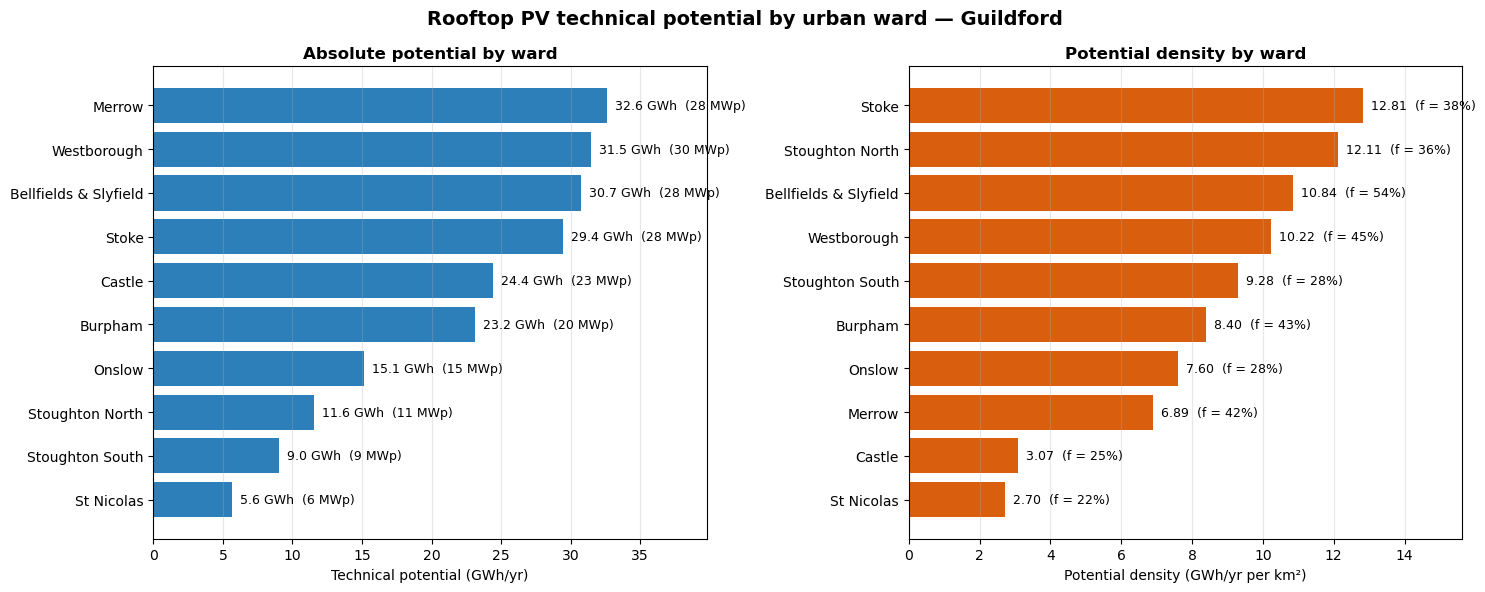

In [11]:
wards = gpd.read_file(WARD_PATH, layer=WARD_LAYER)
if str(wards.crs) != CRS_PROJECTED:
    wards = wards.to_crs(CRS_PROJECTED)

# Every building must be attributed to a ward, or the rollup silently loses potential.
missing = int(res[WARD_COL].isna().sum())
if missing:
    print(f"WARNING: {missing:,} buildings carry no {WARD_COL} and are excluded below.")

ward_stats = (res.groupby(WARD_COL)
                 .agg(buildings          = ("building_id",    "size"),
                      suitable_buildings = ("energy_kwh_yr",  lambda s: int((s > 0).sum())),
                      roof_area_m2       = ("roof_cells_m2",  "sum"),
                      suitable_area_m2   = ("suitable_area_m2", "sum"),
                      incident_kwh_yr    = ("incident_kwh_yr",  "sum"),
                      energy_kwh_yr      = ("energy_kwh_yr",    "sum"),
                      peak_power_kwp     = ("peak_power_kwp",   "sum"))
                 .reset_index())

wards = wards.merge(ward_stats, on=WARD_COL, how="left")

wards["utilization_pct"]   = wards.suitable_area_m2 / wards.roof_area_m2 * 100
wards["potential_gwh_yr"]  = wards.energy_kwh_yr / 1e6
wards["capacity_mwp"]      = wards.peak_power_kwp / 1e3
wards["gwh_per_km2"]       = wards.potential_gwh_yr / wards.ward_area_km2
wards["kwh_per_building"]  = wards.energy_kwh_yr / wards.buildings
wards["suitable_pct"]      = wards.suitable_buildings / wards.buildings * 100

# The rollup must reproduce the study-area totals exactly.
assert wards.buildings.sum() == len(res), "ward rollup lost buildings"
assert abs(wards.energy_kwh_yr.sum() - energy_kwh) / energy_kwh < 1e-9, \
    "ward rollup lost energy"

show = (wards[[WARD_COL, "ward_area_km2", "buildings", "suitable_buildings",
               "suitable_pct", "roof_area_m2", "suitable_area_m2", "utilization_pct",
               "potential_gwh_yr", "capacity_mwp", "gwh_per_km2", "kwh_per_building"]]
        .sort_values("potential_gwh_yr", ascending=False))

print(f"TECHNICAL POTENTIAL BY URBAN WARD — {CITY_NAME}\n")
print(show.rename(columns={
        WARD_COL: "Ward", "ward_area_km2": "Area km2", "buildings": "Bldgs",
        "suitable_buildings": "Suitable", "suitable_pct": "Suit %",
        "roof_area_m2": "Roof m2", "suitable_area_m2": "A_PV m2",
        "utilization_pct": "f %", "potential_gwh_yr": "GWh/yr",
        "capacity_mwp": "MWp", "gwh_per_km2": "GWh/km2",
        "kwh_per_building": "kWh/bldg"})
      .to_string(index=False, float_format=lambda x: f"{x:,.2f}"))

print(f"\n  TOTAL  {wards.buildings.sum():,} buildings, "
      f"{wards.potential_gwh_yr.sum():,.1f} GWh/yr, "
      f"{wards.capacity_mwp.sum():,.1f} MWp "
      f"across {len(wards)} wards ({wards.ward_area_km2.sum():.1f} km2)")
print(f"  Ranking by absolute potential and by density differ: "
      f"largest = {show.iloc[0][WARD_COL]}, "
      f"densest = {wards.loc[wards.gwh_per_km2.idxmax(), WARD_COL]}")

wards.drop(columns="geometry").to_csv(
    os.path.join(DIR_WARD, "ward_potential.csv"), index=False)
wards.to_file(os.path.join(DIR_WARD, "ward_potential.gpkg"), driver="GPKG")

# --- figure: absolute vs density, ranked -------------------------------------
order = wards.sort_values("potential_gwh_yr", ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(order[WARD_COL], order.potential_gwh_yr, color="#2c7fb8")
for y, (v, c) in enumerate(zip(order.potential_gwh_yr, order.capacity_mwp)):
    axes[0].text(v, y, f"  {v:,.1f} GWh  ({c:,.0f} MWp)", va="center", fontsize=9)
axes[0].set_xlabel("Technical potential (GWh/yr)")
axes[0].set_title("Absolute potential by ward", fontweight="bold")
axes[0].margins(x=0.22)
axes[0].grid(axis="x", alpha=0.3)

order2 = wards.sort_values("gwh_per_km2", ascending=True)
axes[1].barh(order2[WARD_COL], order2.gwh_per_km2, color="#d95f0e")
for y, (v, f_) in enumerate(zip(order2.gwh_per_km2, order2.utilization_pct)):
    axes[1].text(v, y, f"  {v:,.2f}  (f = {f_:.0f}%)", va="center", fontsize=9)
axes[1].set_xlabel("Potential density (GWh/yr per km²)")
axes[1].set_title("Potential density by ward", fontweight="bold")
axes[1].margins(x=0.22)
axes[1].grid(axis="x", alpha=0.3)

fig.suptitle(f"Rooftop PV technical potential by urban ward — {CITY_NAME}",
             fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(DIR_WARD, "fig_ward_potential.png"),
            dpi=150, bbox_inches="tight")
plt.show()

---
## Cell 11 — Town-level totals and the shape of the resource

The town aggregate, plus the distribution behind it. The headline GWh figure hides the fact
that rooftop potential is extremely unevenly distributed: a small minority of buildings
carries a large share of the resource, which is what determines whether a programme should
target many small roofs or few large ones.

  GUILDFORD TOWN — TOTAL ROOFTOP PV POTENTIAL
  study_area                 Guildford town
  area_km2                   29.67
  wards                      10
  buildings                  25,798
  buildings_with_pv          19,455
  addresses                  42,059
  addresses_with_pv          33,021
  roof_area_m2               2,690,206.00
  suitable_area_m2           987,399.00
  utilization_pct            36.70
  incident_gwh_yr            1,066.24
  technical_potential_gwh    213.25
  capacity_mwp               197.48
  gwh_per_km2                7.19
  kwh_per_address            5,070.23

Concentration of the resource (suitable buildings ranked by yield):
  top   5% of buildings (   972) carry  44.7% of the potential
  top  10% of buildings ( 1,945) carry  52.5% of the potential
  top  25% of buildings ( 4,863) carry  67.3% of the potential
  top  50% of buildings ( 9,727) carry  83.3% of the potential
  50% of the potential comes from the top 1,586 buildings (8.2%)
  80% of the p

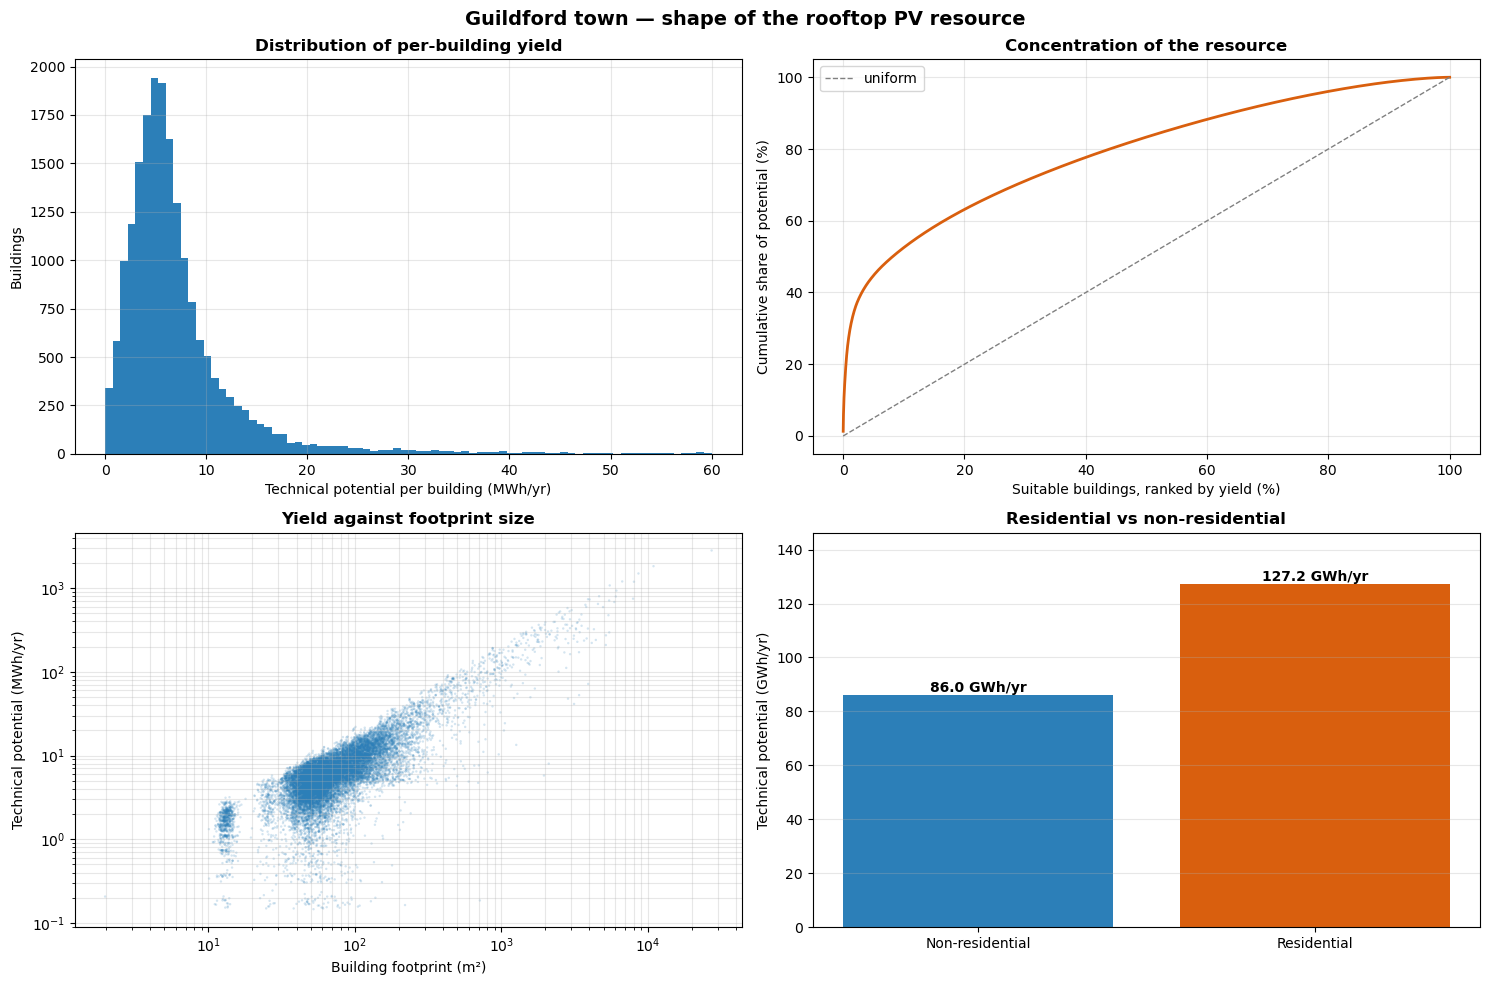

In [12]:
town_row = {
    "study_area"              : f"{CITY_NAME} town",
    "area_km2"                : town_km2,
    "wards"                   : len(wards),
    "buildings"               : len(res),
    "buildings_with_pv"       : int((res.energy_kwh_yr > 0).sum()),
    "addresses"               : int(len(addr)),
    "addresses_with_pv"       : int((addr.energy_kwh_yr_share > 0).sum()),
    "roof_area_m2"            : float(res.roof_cells_m2.sum()),
    "suitable_area_m2"        : float(res.suitable_area_m2.sum()),
    "utilization_pct"         : float(res.suitable_area_m2.sum() / res.roof_cells_m2.sum() * 100),
    "incident_gwh_yr"         : float(res.incident_kwh_yr.sum() / 1e6),
    "technical_potential_gwh" : float(res.energy_kwh_yr.sum() / 1e6),
    "capacity_mwp"            : float(res.peak_power_kwp.sum() / 1e3),
    "gwh_per_km2"             : float(res.energy_kwh_yr.sum() / 1e6 / town_km2),
    "kwh_per_address"         : float(res.energy_kwh_yr.sum() / len(addr)),
}
town_summary = pd.DataFrame([town_row]).T.rename(columns={0: "value"})

print("=" * 74)
print(f"  {CITY_NAME.upper()} TOWN — TOTAL ROOFTOP PV POTENTIAL")
print("=" * 74)
for k, v in town_row.items():
    print(f"  {k:<26s} {v:,.2f}" if isinstance(v, float) else
          f"  {k:<26s} {v:,}" if isinstance(v, int) else f"  {k:<26s} {v}")
print("=" * 74)

# --- concentration of the resource -------------------------------------------
e = np.sort(pv.energy_kwh_yr.to_numpy())[::-1]
cum = np.cumsum(e) / e.sum()
print("\nConcentration of the resource (suitable buildings ranked by yield):")
for frac in (0.05, 0.10, 0.25, 0.50):
    k = max(1, int(len(e) * frac))
    print(f"  top {frac:4.0%} of buildings ({k:>6,}) carry {cum[k-1]*100:5.1f}% of the potential")
for share in (0.5, 0.8):
    k = int(np.searchsorted(cum, share) + 1)
    print(f"  {share:.0%} of the potential comes from the top {k:,} buildings "
          f"({k/len(e)*100:.1f}%)")

res_only = res[res.is_residential & (res.energy_kwh_yr > 0)]
non_res  = res[~res.is_residential & (res.energy_kwh_yr > 0)]
_n_dis = int((res.use_class_final.eq("Residential") != res.is_residential).sum())
print(f"\nResidential vs non-residential"
      f"  [flag = membership of {os.path.basename(RESIDENTIAL_PATH)};"
      f" the use-class table groups by use_class_final instead,"
      f" which differs on {_n_dis:,} buildings]:")
print(f"  residential     : {len(res_only):>6,} buildings, "
      f"{res_only.energy_kwh_yr.sum()/1e6:6.1f} GWh/yr "
      f"({res_only.energy_kwh_yr.sum()/res.energy_kwh_yr.sum()*100:4.1f}%), "
      f"median {res_only.energy_kwh_yr.median():,.0f} kWh/yr")
print(f"  non-residential : {len(non_res):>6,} buildings, "
      f"{non_res.energy_kwh_yr.sum()/1e6:6.1f} GWh/yr "
      f"({non_res.energy_kwh_yr.sum()/res.energy_kwh_yr.sum()*100:4.1f}%), "
      f"median {non_res.energy_kwh_yr.median():,.0f} kWh/yr")

town_summary.to_csv(os.path.join(DIR_TOWN, "town_totals.csv"))
print(f"\nWritten: {os.path.join(DIR_TOWN, 'town_totals.csv')}")

# --- figure: the shape of the resource ---------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(pv.energy_kwh_yr / 1e3, bins=80, range=(0, 60), color="#2c7fb8")
axes[0, 0].set_xlabel("Technical potential per building (MWh/yr)")
axes[0, 0].set_ylabel("Buildings")
axes[0, 0].set_title("Distribution of per-building yield", fontweight="bold")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(np.arange(1, len(cum) + 1) / len(cum) * 100, cum * 100,
                color="#d95f0e", linewidth=2)
axes[0, 1].plot([0, 100], [0, 100], "--", color="grey", linewidth=1, label="uniform")
axes[0, 1].set_xlabel("Suitable buildings, ranked by yield (%)")
axes[0, 1].set_ylabel("Cumulative share of potential (%)")
axes[0, 1].set_title("Concentration of the resource", fontweight="bold")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].scatter(pv.footprint_m2, pv.energy_kwh_yr / 1e3, s=3, alpha=0.2,
                   color="#2c7fb8", edgecolors="none")
axes[1, 0].set_xscale("log"); axes[1, 0].set_yscale("log")
axes[1, 0].set_xlabel("Building footprint (m²)")
axes[1, 0].set_ylabel("Technical potential (MWh/yr)")
axes[1, 0].set_title("Yield against footprint size", fontweight="bold")
axes[1, 0].grid(alpha=0.3, which="both")

byuse = (res.groupby("is_residential")
            .agg(gwh=("energy_kwh_yr", lambda s: s.sum() / 1e6)).reset_index())
byuse["label"] = np.where(byuse.is_residential, "Residential", "Non-residential")
axes[1, 1].bar(byuse.label, byuse.gwh, color=["#2c7fb8", "#d95f0e"])
for i, v in enumerate(byuse.gwh):
    axes[1, 1].text(i, v, f"{v:,.1f} GWh/yr", ha="center", va="bottom", fontweight="bold")
axes[1, 1].set_ylabel("Technical potential (GWh/yr)")
axes[1, 1].set_title("Residential vs non-residential", fontweight="bold")
axes[1, 1].margins(y=0.15)
axes[1, 1].grid(axis="y", alpha=0.3)

fig.suptitle(f"{CITY_NAME} town — shape of the rooftop PV resource",
             fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(DIR_TOWN, "fig_town_resource_shape.png"),
            dpi=150, bbox_inches="tight")
plt.show()

---
## Cell 12 — Filtering stages (paper Figure 6)

A window over the densest built-up block, showing the same six panels the paper uses:
raw input, cropped to footprints, after the cut-off, after Moore, after Von Neumann, and
after the patch-area cut-off.

Figure window at row 350, col 3500 (68,834 suitable cells)


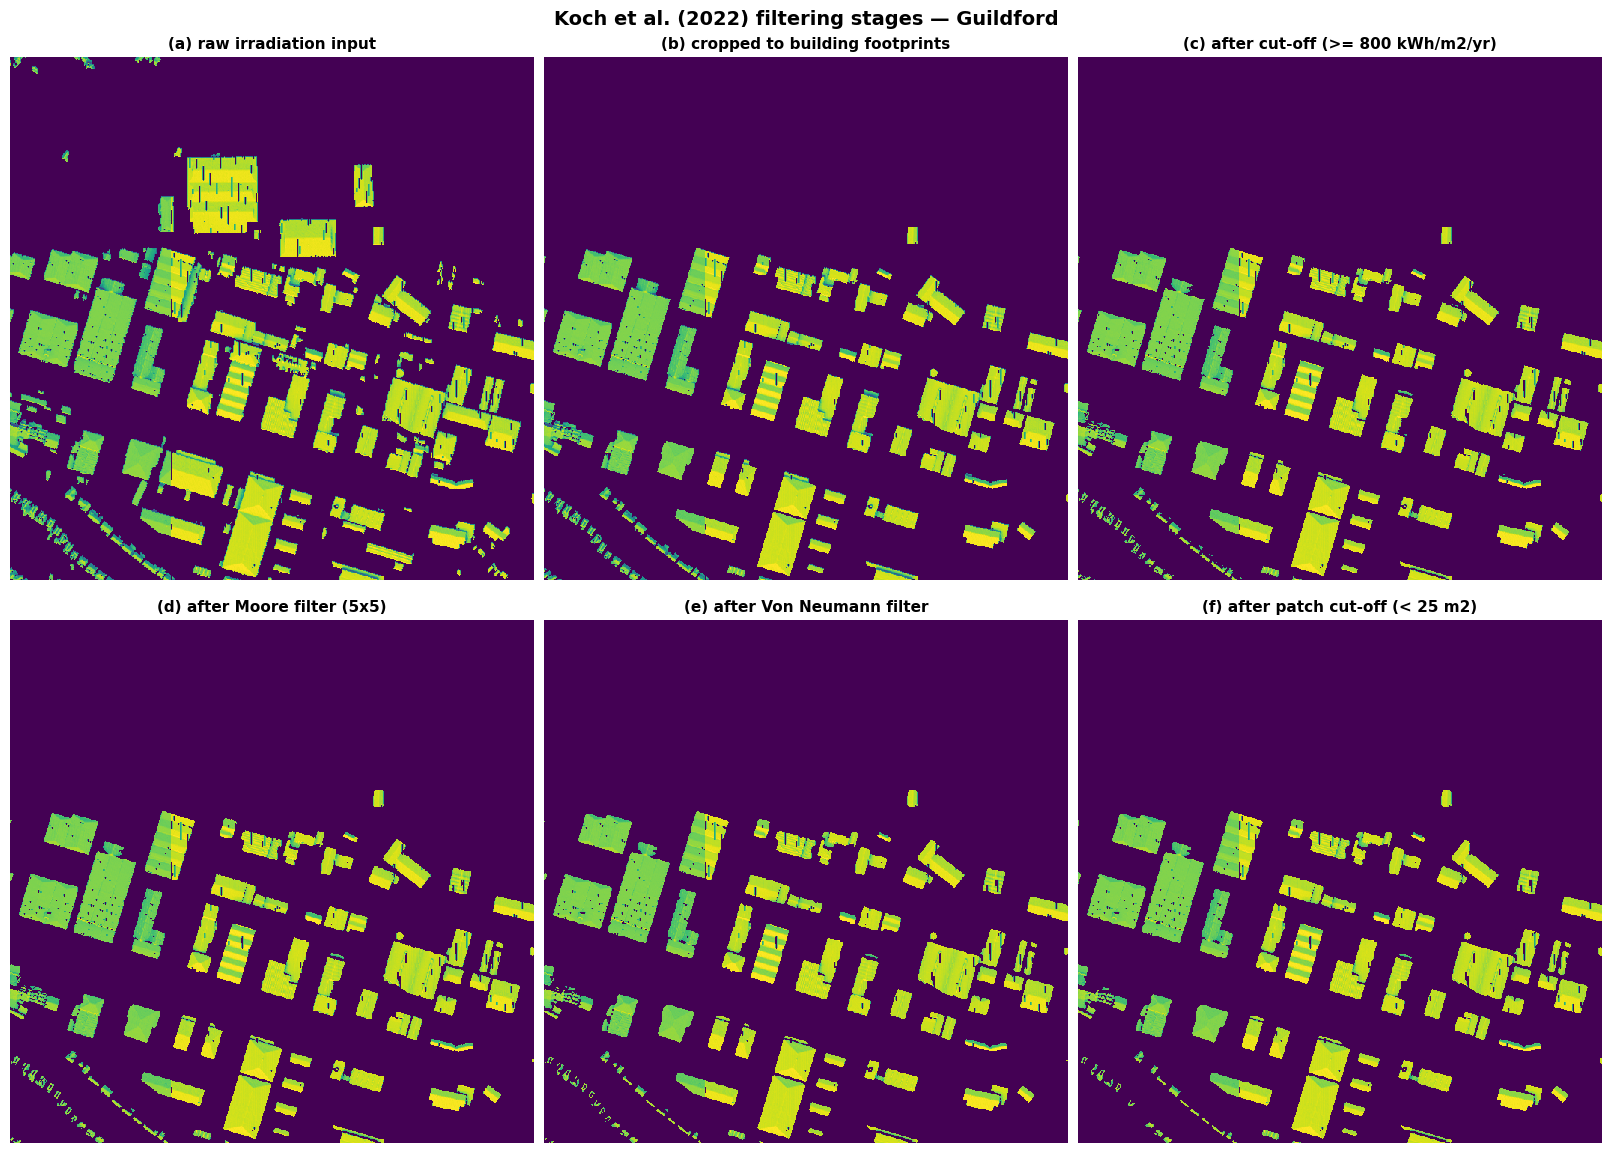


                    stage   cells  area_ha  retained_pct                                    detail
(a) cropped to footprints 2291945    229.2         100.0                                          
  (b) irradiation cut-off 1628205    162.8          71.0                          >= 800 kWh/m2/yr
         (c) Moore filter 1484049    148.4          91.1                5x5, zero if nb <= 8 of 24
   (d) Von Neumann filter 1190331    119.0          80.2                      zero if nb <= 2 of 4
   (e) patch area cut-off 1097110    109.7          92.2 < 25 m2 dropped; 10,033 of 21,899 patches


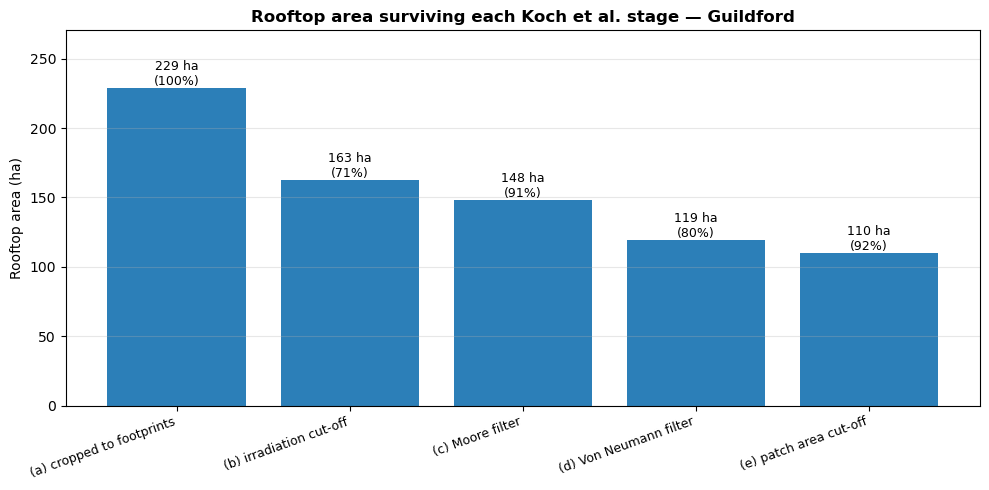

In [13]:
# Pick the densest 700 x 700 window so the panels show recognisable buildings
WIN = 700
best, origin = -1, (0, 0)
step = WIN // 2
for r0 in range(0, irrad.shape[0] - WIN, step):
    for c0 in range(0, irrad.shape[1] - WIN, step):
        n = int(suitable[r0:r0 + WIN, c0:c0 + WIN].sum())
        if n > best:
            best, origin = n, (r0, c0)
r0, c0 = origin
sl = (slice(r0, r0 + WIN), slice(c0, c0 + WIN))
print(f"Figure window at row {r0}, col {c0} ({best:,} suitable cells)")

# Re-run the chain on the window so every intermediate panel is available
w_irrad = irrad[sl]
w_crop  = irrad_cropped[sl]
m0 = w_crop > 0
m1 = m0 & (w_crop >= IRRAD_CUTOFF_KWH)
m2 = koch_filter(m1, moore_offsets(MOORE_SIZE),
                 int(np.floor(round(MOORE_COEFF * (MOORE_SIZE ** 2 - 1), 9))))
m3 = koch_filter(m2, VON_NEUMANN_OFFSETS, VN_THRESHOLD)
m4 = suitable[sl]

vmax = float(np.percentile(w_irrad[w_irrad > 0], 99)) if (w_irrad > 0).any() else 1.0
panels = [
    (w_irrad,                     "(a) raw irradiation input"),
    (w_crop,                      "(b) cropped to building footprints"),
    (np.where(m1, w_crop, 0.0),   f"(c) after cut-off (>= {IRRAD_CUTOFF_KWH:.0f} kWh/m2/yr)"),
    (np.where(m2, w_crop, 0.0),   f"(d) after Moore filter ({MOORE_SIZE}x{MOORE_SIZE})"),
    (np.where(m3, w_crop, 0.0),   "(e) after Von Neumann filter"),
    (np.where(m4, w_crop, 0.0),   f"(f) after patch cut-off (< {MIN_AREA_M2:.0f} m2)"),
]

# constrained_layout, not tight_layout: the panels are square and axis-less, so
# tight_layout lets the second row's titles ride up over the first row's images.
fig, axes = plt.subplots(2, 3, figsize=(16, 11.5), constrained_layout=True)
for ax, (arr, title) in zip(axes.flat, panels):
    ax.imshow(arr, cmap="viridis", vmin=0, vmax=vmax, interpolation="nearest")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.axis("off")
fig.suptitle(f"Koch et al. (2022) filtering stages — {CITY_NAME}",
             fontsize=14, fontweight="bold")
fig.savefig(os.path.join(DIR_TOWN, "fig_town_filter_stages.png"),
            dpi=150, bbox_inches="tight")
plt.show()

# Stage log as a table + waterfall
print()
print(stage_log[["stage", "cells", "area_ha", "retained_pct", "detail"]]
      .to_string(index=False, float_format=lambda x: f"{x:,.1f}"))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(stage_log["stage"], stage_log["area_ha"], color="#2c7fb8")
for i, (a, p) in enumerate(zip(stage_log["area_ha"], stage_log["retained_pct"])):
    ax.text(i, a, f"{a:,.0f} ha\n({p:.0f}%)", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Rooftop area (ha)")
ax.set_title(f"Rooftop area surviving each Koch et al. stage — {CITY_NAME}",
             fontweight="bold")
ax.set_xticks(range(len(stage_log)))
ax.set_xticklabels(stage_log["stage"], rotation=20, ha="right", fontsize=9)
ax.margins(y=0.18)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(DIR_TOWN, "fig_town_stage_waterfall.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## Sensitivity to filter settings

I vary the irradiation cut-off and neighbourhood settings. This matters because the Guildford raster is 1 m per cell, while the reference study used 0.5 m cells.


Parameter sweep (paper Figure 9 grid) — 15 full pipeline runs



  cut-off      700      ->  1.366 km2 suitable, f = 45.7% / 53.6%


  cut-off      800      ->  1.097 km2 suitable, f = 36.7% / 43.1%


  cut-off      900      ->  0.795 km2 suitable, f = 26.6% / 31.2%


  cut-off      1000     ->  0.516 km2 suitable, f = 17.3% / 20.3%


...

  Moore coeff  0.25     ->  1.144 km2 suitable, f = 38.3% / 44.9%


  Moore coeff  0.3333333333333333 ->  1.097 km2 suitable, f = 36.7% / 43.1%


  Moore coeff  0.5      ->  0.883 km2 suitable, f = 29.5% / 34.7%


  Moore coeff  0.6666666666666666 ->  0.569 km2 suitable, f = 19.0% / 22.3%


  Moore coeff  0.75     ->  0.442 km2 suitable, f = 14.8% / 17.4%


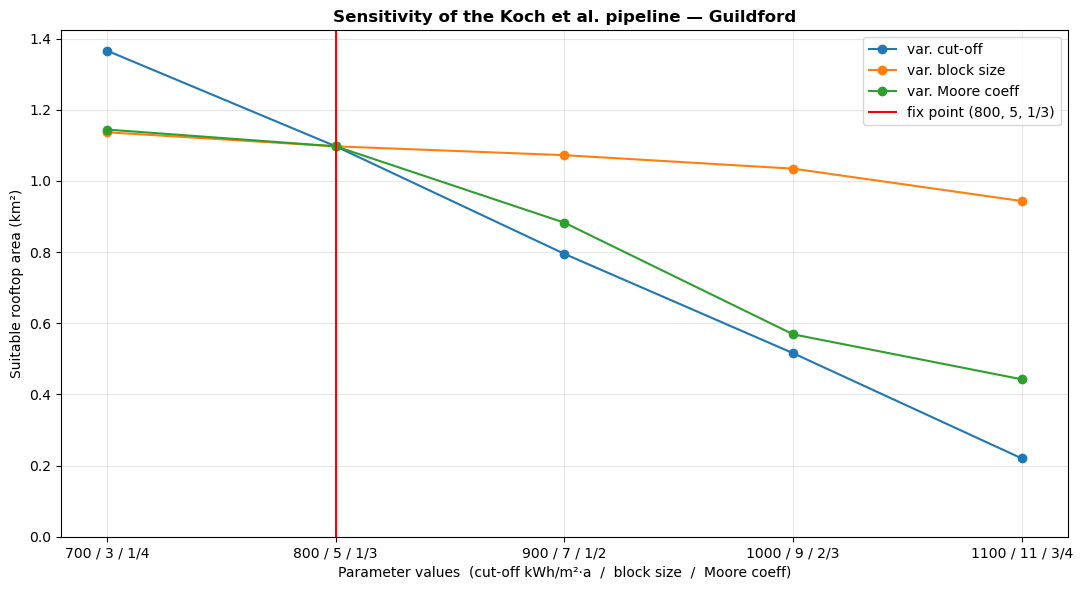

In [14]:
def sweep(cutoffs=None, sizes=None, coeffs=None):
    base = dict(cutoff=IRRAD_CUTOFF_KWH, moore_size=MOORE_SIZE,
                moore_coeff=MOORE_COEFF, vn_threshold=VN_THRESHOLD,
                min_area_m2=MIN_AREA_M2, cell_area=px_area,
                connectivity=PATCH_CONNECTIVITY, verbose=False)
    out = []
    for name, values, key in (("cut-off", cutoffs or [], "cutoff"),
                              ("block size", sizes or [], "moore_size"),
                              ("Moore coeff", coeffs or [], "moore_coeff")):
        for v in values:
            kw = dict(base); kw[key] = v
            mask, _ = koch_pipeline(irrad_cropped, **kw)
            n = int(mask.sum())
            out.append({"parameter": name, "value": v,
                        "suitable_km2": n * px_area / 1e6,
                        "A_PV_m2": n * px_area * CMOD,
                        "f_footprint_pct": n * px_area * CMOD / A_R_footprint * 100,
                        "f_modelled_pct":  n * px_area * CMOD / A_R_modelled * 100})
            print(f"  {name:<12s} {str(v):<8s} -> {n*px_area/1e6:6.3f} km2 "
                  f"suitable, f = {out[-1]['f_footprint_pct']:.1f}% / "
                  f"{out[-1]['f_modelled_pct']:.1f}%")
    return pd.DataFrame(out)


if RUN_SENSITIVITY:
    print("Parameter sweep (paper Figure 9 grid) — 15 full pipeline runs\n")
    sens = sweep(cutoffs=[700, 800, 900, 1000, 1100],
                 sizes=[3, 5, 7, 9, 11],
                 coeffs=[1/4, 1/3, 1/2, 2/3, 3/4])
    sens.to_csv(os.path.join(DIR_TOWN, "town_sensitivity.csv"), index=False)

    fig, ax = plt.subplots(figsize=(11, 6))
    for name, colour in [("cut-off", "#1f77b4"), ("block size", "#ff7f0e"),
                         ("Moore coeff", "#2ca02c")]:
        s = sens[sens.parameter == name]
        ax.plot(range(len(s)), s.suitable_km2, "o-", color=colour, label=f"var. {name}")
    ax.axvline(1, color="red", linewidth=1.5, label="fix point (800, 5, 1/3)")
    ax.set_xticks(range(5))
    ax.set_xticklabels(["700 / 3 / 1/4", "800 / 5 / 1/3", "900 / 7 / 1/2",
                        "1000 / 9 / 2/3", "1100 / 11 / 3/4"])
    ax.set_xlabel("Parameter values  (cut-off kWh/m²·a  /  block size  /  Moore coeff)")
    ax.set_ylabel("Suitable rooftop area (km²)")
    ax.set_title(f"Sensitivity of the Koch et al. pipeline — {CITY_NAME}",
                 fontweight="bold")
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim(bottom=0)
    fig.tight_layout()
    fig.savefig(os.path.join(DIR_TOWN, "fig_town_sensitivity.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("RUN_SENSITIVITY = False — skipped.")

---
## Cell 14 — LCOE and the cost-potential curve

**Extension beyond Koch et al.** The paper stops at technical potential (its Figure 1 lists
"economic considerations" as a separate downstream step it does not carry out). Everything
below is additional, using McKenna et al. (2022) cost parameters.

LCOE (GBP/kWh):
  min 0.091   median 0.115   mean 0.116   max 0.155
  UK household electricity price is ~GBP 0.24/kWh for reference
  Buildings below GBP 0.24/kWh: 19,455 of 19,455 (100.0%), carrying 213.2 GWh/yr


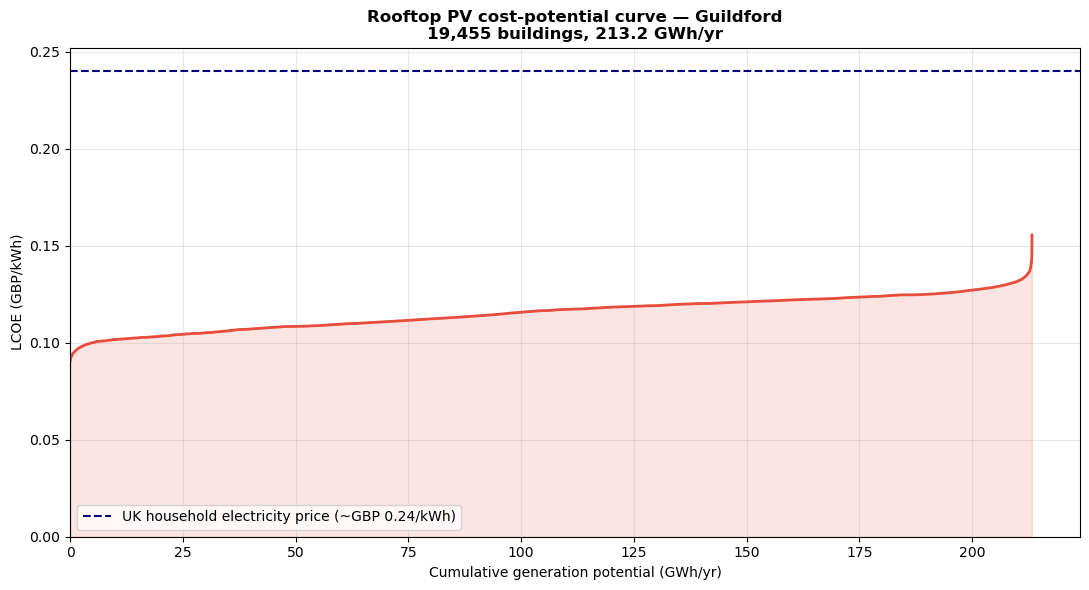

In [15]:
def lcoe(peak_kwp, energy_kwh_yr):
    """Levelised cost of electricity, GBP/kWh (McKenna et al. 2022, Eq. 6)."""
    years    = np.arange(1, LIFETIME_YR + 1)
    discount = (1 + DISCOUNT_RATE) ** years
    annuity  = np.sum(1.0 / discount)
    costs    = INVEST_PER_KW * peak_kwp + OM_PER_KW_YR * peak_kwp * annuity
    energy   = energy_kwh_yr * annuity
    return np.divide(costs, energy, out=np.full_like(costs, np.nan, dtype=float),
                     where=energy > 0)


pv["lcoe_gbp_kwh"] = lcoe(pv["peak_power_kwp"].to_numpy(),
                          pv["energy_kwh_yr"].to_numpy())

print("LCOE (GBP/kWh):")
print(f"  min {pv.lcoe_gbp_kwh.min():.3f}   median {pv.lcoe_gbp_kwh.median():.3f}   "
      f"mean {pv.lcoe_gbp_kwh.mean():.3f}   max {pv.lcoe_gbp_kwh.max():.3f}")
print(f"  UK household electricity price is ~GBP 0.24/kWh for reference")
print(f"  Buildings below GBP 0.24/kWh: "
      f"{int((pv.lcoe_gbp_kwh < 0.24).sum()):,} of {len(pv):,} "
      f"({(pv.lcoe_gbp_kwh < 0.24).mean()*100:.1f}%), carrying "
      f"{pv.loc[pv.lcoe_gbp_kwh < 0.24, 'energy_kwh_yr'].sum()/1e6:,.1f} GWh/yr")

curve = pv.sort_values("lcoe_gbp_kwh").dropna(subset=["lcoe_gbp_kwh"]).copy()
curve["cumulative_gwh"] = curve["energy_kwh_yr"].cumsum() / 1e6

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(curve.cumulative_gwh, curve.lcoe_gbp_kwh, color="#e74c3c", linewidth=2)
ax.fill_between(curve.cumulative_gwh, curve.lcoe_gbp_kwh, alpha=0.15, color="#e74c3c")
ax.axhline(0.24, color="navy", linestyle="--", linewidth=1.5,
           label="UK household electricity price (~GBP 0.24/kWh)")
ax.set_xlabel("Cumulative generation potential (GWh/yr)")
ax.set_ylabel("LCOE (GBP/kWh)")
ax.set_title(f"Rooftop PV cost-potential curve — {CITY_NAME}\n"
             f"{len(curve):,} buildings, {curve.energy_kwh_yr.sum()/1e6:,.1f} GWh/yr",
             fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
fig.tight_layout()
fig.savefig(os.path.join(DIR_TOWN, "fig_town_cost_potential.png"),
            dpi=150, bbox_inches="tight")
plt.show()

---
## Cell 15 — Interactive town map (leafmap)

Study-area overview: the town boundary, the ward divisions inside it, and the suitable-roof
raster itself drawn as an image overlay so the actual classified roofs are visible rather
than a per-building abstraction. The overlay is embedded as a PNG data URI, so the saved
HTML is self-contained and needs no tile server.

In [16]:
import base64
from io import BytesIO
import leafmap.foliumap as leafmap
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds

town_wgs  = town.to_crs(CRS_GEOGRAPHIC)
wards_wgs = wards.to_crs(CRS_GEOGRAPHIC)

m_town = leafmap.Map(center=[CITY_LAT, CITY_LON], zoom=12, tiles=None,
                     draw_control=False, measure_control=False)
m_town.add_basemap("CartoDB.DarkMatter")
m_town.add_basemap("SATELLITE", show=False)
m_town.add_basemap("CartoDB.Positron", show=False)

# --- suitable-roof raster as an RGBA image overlay ----------------------------
# The array MUST be reprojected to EPSG:4326 before it is encoded. Leaflet stretches an
# ImageOverlay linearly between two corner LatLngs, so it can only place a north-up
# lat/lon image. A British National Grid raster is rotated relative to true north by the
# grid convergence (1.12 deg here), and its lat/lon *bounding box* is larger than the
# raster itself, so encoding the native array and passing transform_bounds() shears the
# image onto the map - measured at up to 155 m of misplacement, which is more than a
# building. Warping first costs one call and puts the roofs where they actually are.
STRIDE = 2
dst_tr, dw, dh = calculate_default_transform(
    ras_crs, CRS_GEOGRAPHIC, irrad_suitable.shape[1], irrad_suitable.shape[0], *ras_bounds,
    dst_width=irrad_suitable.shape[1] // STRIDE,
    dst_height=irrad_suitable.shape[0] // STRIDE)

sub = np.zeros((dh, dw), np.float32)
reproject(irrad_suitable, sub,
          src_transform=ras_transform, src_crs=ras_crs,
          dst_transform=dst_tr, dst_crs=CRS_GEOGRAPHIC,
          resampling=Resampling.max)      # max, so thin roof strips survive downsampling

vmax_r = float(np.percentile(sub[sub > 0], 99)) if (sub > 0).any() else 1.0
rgba = plt.cm.plasma(np.clip(sub / vmax_r, 0, 1), bytes=True)
rgba[..., 3] = np.where(sub > 0, 255, 0).astype(np.uint8)   # zero cells fully transparent

buf = BytesIO()
plt.imsave(buf, rgba, format="png")
uri = "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode()

w, s_, e, n = array_bounds(dh, dw, dst_tr)     # bounds of the WARPED grid, not the native one
folium.raster_layers.ImageOverlay(
    image=uri, bounds=[[s_, w], [n, e]], opacity=0.85,
    name="Suitable roof irradiation", overlay=True, show=True,
).add_to(m_town)

# --- boundaries ---------------------------------------------------------------
m_town.add_gdf(
    wards_wgs[[WARD_COL, "ward_area_km2", "geometry"]],
    layer_name="Wards", zoom_to_layer=False, info_mode="on_hover",
    style_function=lambda f: {"color": "#00e5ff", "weight": 1.6,
                              "opacity": 0.85, "fill": False},
)
m_town.add_gdf(
    town_wgs[[c for c in ("name", "area_km2") if c in town_wgs.columns] + ["geometry"]],
    layer_name="Town boundary", zoom_to_layer=False, info_mode="on_hover",
    style_function=lambda f: {"color": "#ffffff", "weight": 3,
                              "opacity": 1.0, "fill": False},
)

town_map_path = os.path.join(DIR_TOWN, "map_town_overview.html")
m_town.to_html(town_map_path)
print(f"Town overview map -> {town_map_path}")
print(f"  raster overlay: {sub.shape[1]:,} x {sub.shape[0]:,} px, warped to "
      f"{CRS_GEOGRAPHIC}, {len(uri)/1e6:.1f} MB data URI, "
      f"colour scale 0-{vmax_r:,.0f} kWh/m2/yr")
m_town

Town overview map -> outputs\town\map_town_overview.html
  raster overlay: 3,962 x 2,955 px, warped to EPSG:4326, 2.0 MB data URI, colour scale 0-1,414 kWh/m2/yr


[Review copy: large cached report or log omitted; calculation code is retained.]


---
## Cell 16 — Interactive ward map (leafmap)

Three deliberate choices, because a continuous ramp on a light basemap is what made the
previous map unreadable:

- **Quantile classes, not a linear ramp.** Rooftop yield is heavily right-skewed, so scaling
  linearly to the maximum pushes almost every polygon into the bottom of the colour ramp.
  Equal-count classes spread the visual range across the data that actually exists.
- **A dark basemap.** `plasma` on `CartoDB.DarkMatter` separates cleanly; pale yellow on a
  white basemap does not. Satellite and light basemaps are attached as toggleable layers.
- **A real legend**, so the colours have units.

In [17]:
import leafmap.foliumap as leafmap

wards_wgs = wards.to_crs(CRS_GEOGRAPHIC)

# leafmap's folium backend ignores `style` / `hover_style` (those are ipyleaflet-only) and
# silently drops them, so styling has to go through style_function / highlight_function.
# `classify` writes the class colour onto each feature as a "color" property; read it back
# so the choropleth ramp survives while still setting our own borders and opacity.
def choro_style(feat):
    return {"fillColor": feat["properties"]["color"], "color": "#ffffff",
            "weight": 1.4, "opacity": 1.0, "fillOpacity": 0.72}


def choro_hover(feat):
    return {"fillColor": feat["properties"]["color"], "color": "#00e5ff",
            "weight": 4, "opacity": 1.0, "fillOpacity": 0.92}


# tiles=None, then add_basemap: leafmap.foliumap.Map has no `basemap` parameter -- it
# forwards unknown kwargs to folium.Map, which would silently ignore it and leave the
# default OpenStreetMap tiles. The first basemap added becomes the base layer.
m_ward = leafmap.Map(center=[CITY_LAT, CITY_LON], zoom=12, tiles=None,
                     draw_control=False, measure_control=False)
m_ward.add_basemap("CartoDB.DarkMatter")
m_ward.add_basemap("SATELLITE", show=False)     # Esri World Imagery, no API key needed
m_ward.add_basemap("CartoDB.Positron", show=False)

m_ward.add_data(
    wards_wgs, column="potential_gwh_yr", cmap=MAP_CMAP,
    scheme=MAP_SCHEME, k=min(5, len(wards_wgs)),
    layer_name="Potential (GWh/yr)",
    legend_title="Technical potential (GWh/yr)",
    style_function=choro_style, highlight_function=choro_hover,
    info_mode="on_hover",
)

m_ward.add_data(
    wards_wgs, column="gwh_per_km2", cmap="viridis",
    scheme=MAP_SCHEME, k=min(5, len(wards_wgs)),
    layer_name="Potential density (GWh/yr/km2)",
    legend_title="GWh/yr per km2",
    style_function=choro_style, highlight_function=choro_hover,
    info_mode="on_hover", show=False,
)

ward_map_path = os.path.join(DIR_WARD, "map_ward_potential.html")
m_ward.to_html(ward_map_path)
print(f"Ward map ({len(wards_wgs)} wards) -> {ward_map_path}")
print("Layers: absolute potential (on), potential density (off), "
      "basemaps dark / satellite / light")
m_ward

Ward map (10 wards) -> outputs\ward\map_ward_potential.html
Layers: absolute potential (on), potential density (off), basemaps dark / satellite / light


[Review copy: embedded interactive output or widget payload omitted; calculation code is retained.]


---
## Cell 17 — Interactive building map (leafmap)

Same treatment at building level. Hover any roof for its yield, suitable area, capacity and
LCOE. Only the top `MAP_TOP_N` buildings by yield are drawn — all 25 k would produce an
unusable file — and the count actually rendered is printed so the map is never mistaken for
the full set.

In [18]:
top = pv.nlargest(min(MAP_TOP_N, len(pv)), "energy_kwh_yr").copy()
top_wgs = top.to_crs(CRS_GEOGRAPHIC)
top_wgs["geometry"] = top_wgs.geometry.simplify(0.000015)

# Round for readable hover boxes
show_cols = ["geometry", "energy_kwh_yr", "suitable_area_m2",
             "peak_power_kwp", "lcoe_gbp_kwh", "mean_irrad_kwh_m2", WARD_COL]
bmap = top_wgs[show_cols].copy()
for c, nd in [("energy_kwh_yr", 0), ("suitable_area_m2", 0),
              ("peak_power_kwp", 1), ("lcoe_gbp_kwh", 3),
              ("mean_irrad_kwh_m2", 0)]:
    bmap[c] = bmap[c].round(nd)

m_bld = leafmap.Map(center=[CITY_LAT, CITY_LON], zoom=14, tiles=None,
                    draw_control=False, measure_control=False)
m_bld.add_basemap("CartoDB.DarkMatter")
m_bld.add_basemap("SATELLITE", show=False)      # compare classified roofs to imagery
m_bld.add_basemap("CartoDB.Positron", show=False)

# Ward outlines for orientation. add_gdf, not add_data: there is no numeric column to
# classify here, and an unfilled outline must not compete with the buildings underneath.
m_bld.add_gdf(
    wards_wgs[[WARD_COL, "potential_gwh_yr", "geometry"]],
    layer_name="Ward boundaries", zoom_to_layer=False, info_mode="on_hover",
    style_function=lambda f: {"color": "#00e5ff", "weight": 2.5,
                              "opacity": 0.9, "fill": False},
)

m_bld.add_data(
    bmap, column="energy_kwh_yr", cmap=MAP_CMAP,
    scheme=MAP_SCHEME, k=MAP_CLASSES,
    layer_name=f"Top {len(bmap):,} buildings by yield",
    legend_title="Technical potential (kWh/yr)",
    style_function=lambda f: {"fillColor": f["properties"]["color"],
                              "color": f["properties"]["color"],
                              "weight": 0.4, "opacity": 1.0, "fillOpacity": 0.92},
    highlight_function=lambda f: {"fillColor": f["properties"]["color"],
                                  "color": "#ffffff", "weight": 2.5,
                                  "opacity": 1.0, "fillOpacity": 1.0},
    info_mode="on_hover",
)

map_path = os.path.join(DIR_BUILDING, "map_building_potential.html")
m_bld.to_html(map_path)
print(f"Building map: top {len(bmap):,} of {len(pv):,} suitable buildings "
      f"({bmap.energy_kwh_yr.sum()/1e6:,.1f} of {pv.energy_kwh_yr.sum()/1e6:,.1f} GWh/yr, "
      f"{bmap.energy_kwh_yr.sum()/pv.energy_kwh_yr.sum()*100:.0f}% of the total)")
print(f"  -> {map_path}")
print(f"  Classification: {MAP_SCHEME}, {MAP_CLASSES} classes, cmap '{MAP_CMAP}'")
m_bld

Building map: top 3,000 of 19,455 suitable buildings (125.3 of 213.2 GWh/yr, 59% of the total)
  -> outputs\building\map_building_potential.html
  Classification: Quantiles, 7 classes, cmap 'plasma'


[Review copy: large cached report or log omitted; calculation code is retained.]


---
## Cell 18 — Summary and export

In [19]:
summary = pd.DataFrame({
    "Parameter": [
        "Study area", "Methodology", "Irradiation input", "Footprint input",
        "Raster resolution", "Urban wards",
        "Buildings in study area", "Buildings suitable for PV", "Suitability rate",
        "Total rooftop area A_R (footprint)", "Total rooftop area A_R (modelled)",
        "Suitable rooftop area A_PV (after c_mod)",
        "Utilization factor f (A_R = footprint)",
        "Utilization factor f (A_R = modelled)",
        "Koch et al. Giessen utilization factor",
        "Mean irradiation on suitable roof",
        "Incident irradiation on suitable roof",
        "Technical potential", "Installed capacity", "Mean specific yield", "Mean LCOE",
        "Irradiation cut-off", "Moore neighbourhood", "Moore threshold",
        "Von Neumann threshold", "Patch area cut-off", "Correction factor c_mod",
        "Overall system efficiency",
    ],
    "Value": [
        CITY_NAME, "Koch et al. (2022), Energies 15, 6991",
        os.path.basename(IRRAD_PATH), os.path.basename(FOOTPRINT_PATH),
        f"{pixel_size:g} m",
        f"{len(wards)} ({wards.ward_area_km2.sum():.1f} km2)",
        f"{len(res):,}", f"{len(pv):,}", f"{len(pv)/len(res)*100:.1f}%",
        f"{A_R_footprint:,.0f} m2", f"{A_R_modelled:,.0f} m2",
        f"{A_PV:,.0f} m2 ({A_PV/1e4:,.1f} ha)",
        f"{f_footprint*100:.1f}%", f"{f_modelled*100:.1f}%", "43.5%",
        f"{mean_irrad:,.0f} kWh/m2/yr",
        f"{irr_sum/1e6:,.1f} GWh/yr",
        f"{energy_kwh/1e6:,.1f} GWh/yr",
        f"{pv.peak_power_kwp.sum()/1e3:,.1f} MWp",
        f"{pv.energy_kwh_yr.sum()/pv.peak_power_kwp.sum():,.0f} kWh/kWp/yr",
        f"GBP {pv.lcoe_gbp_kwh.mean():.3f}/kWh",
        f"{IRRAD_CUTOFF_KWH:.0f} kWh/m2/yr",
        f"{MOORE_SIZE}x{MOORE_SIZE} ({MOORE_SIZE**2-1} neighbours)",
        f"zero if non-zero neighbours <= "
        f"{int(np.floor(round(MOORE_COEFF*(MOORE_SIZE**2-1), 9)))}",
        f"zero if non-zero neighbours <= {VN_THRESHOLD}",
        f"{MIN_AREA_M2:.0f} m2", f"{CMOD}", f"{SYSTEM_EFF:.0%}",
    ],
})

print("=" * 78)
print(f"  {CITY_NAME.upper()} ROOFTOP PV POTENTIAL — SUMMARY")
print("=" * 78)
for _, r in summary.iterrows():
    print(f"  {r['Parameter']:<42s} {r['Value']}")
print("=" * 78)

summary.to_csv(os.path.join(DIR_TOWN, "town_summary.csv"), index=False)
stage_log.to_csv(os.path.join(DIR_TOWN, "town_filter_stages.csv"), index=False)

# Building table: EVERY building in the study area, not only the suitable ones, so the
# zero rows are explicit rather than missing. `uprn_list` is dropped from the GeoPackage
# because a semicolon-delimited string is not a queryable field; it stays in the CSV.
res.drop(columns="geometry").to_csv(
    os.path.join(DIR_BUILDING, "building_potential.csv"), index=False)
gpd.GeoDataFrame(res.drop(columns=[UPRN_LIST_COL]), geometry="geometry",
                 crs=CRS_PROJECTED).to_file(
    os.path.join(DIR_BUILDING, "building_potential.gpkg"), driver="GPKG")

print("\nExports, by spatial unit:")
total_b, total_n = 0, 0
for label, d in [("town", DIR_TOWN), ("ward", DIR_WARD),
                 ("building", DIR_BUILDING), ("raster", DIR_RASTER)]:
    files = sorted(os.listdir(d)) if os.path.isdir(d) else []
    print(f"\n  outputs/{label}/")
    for fn in files:
        sz = os.path.getsize(os.path.join(d, fn))
        total_b += sz; total_n += 1
        print(f"      {fn:<40s} {sz/1e6:8.2f} MB")
print(f"\n  {total_n} files, {total_b/1e6:.1f} MB total")

  GUILDFORD ROOFTOP PV POTENTIAL — SUMMARY
  Study area                                 Guildford
  Methodology                                Koch et al. (2022), Energies 15, 6991
  Irradiation input                          guildford_urban_wards.tif
  Footprint input                            guildford_town_buildings_all.gpkg
  Raster resolution                          1 m
  Urban wards                                10 (29.7 km2)
  Buildings in study area                    25,798
  Buildings suitable for PV                  19,455
  Suitability rate                           75.4%
  Total rooftop area A_R (footprint)         2,690,206 m2
  Total rooftop area A_R (modelled)          2,291,945 m2
  Suitable rooftop area A_PV (after c_mod)   987,399 m2 (98.7 ha)
  Utilization factor f (A_R = footprint)     36.7%
  Utilization factor f (A_R = modelled)      43.1%
  Koch et al. Giessen utilization factor     43.5%
  Mean irradiation on suitable roof          1,080 kWh/m2/yr
  Incident


Exports, by spatial unit:

  outputs/town/
      fig_town_cost_potential.png                  0.07 MB
      fig_town_filter_stages.png                   0.63 MB
      fig_town_resource_shape.png                  0.31 MB
      fig_town_sensitivity.png                     0.12 MB
      fig_town_stage_waterfall.png                 0.08 MB
      map_town_overview.html                       2.06 MB
      town_by_use_class.csv                        0.00 MB
      town_filter_stages.csv                       0.00 MB
      town_sensitivity.csv                         0.00 MB
      town_summary.csv                             0.00 MB
      town_totals.csv                              0.00 MB

  outputs/ward/
      fig_ward_potential.png                       0.16 MB
      map_ward_potential.html                      0.07 MB
      ward_potential.csv                           0.00 MB
      ward_potential.gpkg                          0.11 MB

  outputs/building/
      address_potential.csv      

## Limitations

The result depends on the irradiation raster, the 800 kWh/m²/year cut-off and the chosen filters. Roof edges, obstacles, listed-building constraints and module layout are not resolved here. Equal sharing across UPRNs is an accounting assumption. PV generation is a technical estimate, not an installation forecast.
